# 2110742 Evolutionary Computation
## Final Project: Simplified 2D UAV Path Planning

This notebook studies simplified constrained UAV path planning in a 2D environment with circular obstacles. The comparison is intentionally narrow: a weighted-sum genetic algorithm (GA) and NSGA-II are evaluated under the same representation, budget, and seed protocol, and then re-evaluated after adding the same obstacle-aware repair operator to both methods.

### Research questions
1. Under a common baseline protocol, how do weighted-sum GA and NSGA-II differ in terms of feasible-run rate, shortest feasible path quality, safety margin, and route diversity?
2. When a shared geometric repair operator is added to both methods, how do the results change?
3. What trade-offs are most visible in this simplified path-planning setting, and what conclusions remain justified after accounting for practical modeling choices?

### Notebook roadmap
1. Define the geometry, path representation, objectives, and constraints.
2. Separate tuning seeds from evaluation seeds.
3. Run a fair **baseline comparison**:
   - GA baseline
   - NSGA-II baseline
4. Run a fair **enhanced comparison**:
   - GA + repair
   - NSGA-II + repair
5. Summarize results on benchmark maps using common metrics.
6. Use exploratory analyses only as supporting evidence, not as the primary basis for the final conclusions.

In [1]:
import importlib.util
import subprocess
import sys

EXPERIMENT_OPTIONS = {
    "use_saved_tuning": False,
    "export_profile_snapshot": True,
}

SAVED_EXPERIMENT_STATE = {
    "signature": {
        "n_waypoints": 8,
        "danger_margin": 5.0,
        "required_clearance": 1.5,
    },
    "seed_sets": {
        "tuning": [0, 1, 2, 3, 4, 5],
        "evaluation": list(range(100, 120)),
    },
    "common_protocol": {
        "pop_size": 80,
        "n_gen": 80,
        "crossover_prob": 0.9,
        "crossover_eta": 15,
        "mutation_eta": 20,
        "mutation_prob_factor": 1.0,
    },
    "ga_weight_grid": [80.0, 120.0, 160.0],
    "selected_ga_weight": 120.0,
    "repair_profile": {
        "heuristic_mode": "offspring",
        "repair_kind": "segment",
    },
}

REQUIRED_PACKAGES = ["numpy", "pandas", "matplotlib", "pymoo", "nbformat", "nbclient"]

missing = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]
is_colab = "google.colab" in sys.modules

if is_colab and missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
elif missing:
    print(f"Missing packages: {missing}. Install them in your environment before running the notebook.")
else:
    print("Required packages already available.")

print()
print("Experiment configuration loaded.")
print(f"Use saved tuning state: {EXPERIMENT_OPTIONS['use_saved_tuning']}")
print(f"Tuning seeds: {SAVED_EXPERIMENT_STATE['seed_sets']['tuning']}")
print(f"Evaluation seeds: {SAVED_EXPERIMENT_STATE['seed_sets']['evaluation']}")

Required packages already available.

Experiment configuration loaded.
Use saved tuning state: False
Tuning seeds: [0, 1, 2, 3, 4, 5]
Evaluation seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119]


## 1. Problem definition

The task is a simplified 2D UAV path-planning problem on a square map with circular obstacles. A candidate solution is a polyline that connects a fixed start point to a fixed goal point through a fixed number of optimized intermediate waypoints.

The problem is intentionally simplified:
- motion is planar
- obstacles are static circles
- the path is piecewise linear
- there are no vehicle dynamics, wind, sensing, or time-varying constraints

This simplification is deliberate. It keeps the geometry exact and computationally lightweight while still supporting meaningful constrained optimization experiments.


## 2. Research question

The notebook focuses on two questions.

1. Under a fair shared protocol, how does a weighted-sum **GA** compare with **NSGA-II** on simplified constrained UAV path planning?
2. If the same obstacle-aware repair operator is added to both methods, does it improve either or both algorithms?

The notebook does **not** try to claim a universal winner. The goal is to identify the trade-offs that appear in this simplified setting under a protocol that is easy to explain and defend.


### Reading guide

The main evidence in this notebook is organized around two sections:

- **Baseline comparison results**: a common-budget comparison between weighted-sum GA and NSGA-II without repair
- **Enhanced comparison results**: the same comparison after adding the same obstacle-aware repair operator to both methods

Exploratory sections that appear later in the notebook, such as route-family analysis, are included to help interpret the behavior of the algorithms, but the final conclusions should be based primarily on the benchmark summaries from the baseline and enhanced comparisons.

## 3. Environment and path representation

The workspace is the square domain
$$
\Omega = [0, L]^2,
$$
where `L` is the map size. The start and goal are fixed points `s, g \in \Omega`.

Each obstacle is a closed disk
$$
O_j = \{x \in \mathbb{R}^2 : \|x - c_j\|_2 \le r_j\},
$$
where `c_j` is the obstacle center and `r_j` is the obstacle radius.

A candidate path is encoded as
$$
P = (p_0, p_1, \ldots, p_K, p_{K+1}),
$$
where `p_0 = s`, `p_{K+1} = g`, and the `K` interior waypoints are optimized by the evolutionary algorithms.

The experiments below fix `K = 8` interior waypoints. Circular obstacles are kept on purpose because they allow exact distance and segment-intersection calculations, which makes the evaluator more trustworthy than sampled collision checks.

In [2]:
from __future__ import annotations

from dataclasses import dataclass, replace
import math
from typing import List, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.core.problem import ElementwiseProblem
from pymoo.core.repair import Repair
from pymoo.core.sampling import Sampling
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize

Point = Tuple[float, float]
GA_WEIGHTS = (1.0, 120.0)
POP_SIZE = 80
N_GEN = 80
COMPROMISE_RULE = "Feasible point closest to the normalized ideal point"


In [3]:
@dataclass(frozen=True)
class CircleObstacle:
    cx: float
    cy: float
    radius: float

    def __post_init__(self):
        if self.radius <= 0.0:
            raise ValueError("Obstacle radius must be positive.")

    @property
    def center(self) -> Point:
        return (self.cx, self.cy)

    def signed_distance_to_point(self, point: Point) -> float:
        return math.hypot(point[0] - self.cx, point[1] - self.cy) - self.radius

    def contains_point(self, point: Point, tol: float = 0.0) -> bool:
        return self.signed_distance_to_point(point) <= tol

    def clearance_to_segment(self, p1: Point, p2: Point) -> float:
        return segment_point_distance(p1, p2, self.center) - self.radius

    def intersects_segment(self, p1: Point, p2: Point, tol: float = 1e-9) -> bool:
        return self.clearance_to_segment(p1, p2) <= tol


@dataclass(frozen=True)
class MapConfig:
    size: float = 100.0
    start: Point = (5.0, 5.0)
    goal: Point = (95.0, 95.0)
    n_waypoints: int = 8
    danger_margin: float = 5.0
    required_clearance: float = 1.5
    obstacles: Tuple[CircleObstacle, ...] = (
        CircleObstacle(30, 30, 10),
        CircleObstacle(60, 20, 8),
        CircleObstacle(50, 50, 12),
        CircleObstacle(20, 70, 9),
        CircleObstacle(75, 60, 10),
        CircleObstacle(40, 85, 7),
        CircleObstacle(85, 35, 8),
        CircleObstacle(65, 80, 6),
        CircleObstacle(15, 45, 6),
        CircleObstacle(55, 10, 5),
        CircleObstacle(80, 80, 7),
        CircleObstacle(35, 60, 8),
    )


def point_inside_any_obstacle(point: Point, obstacles: Sequence[CircleObstacle]) -> bool:
    return any(obs.contains_point(point) for obs in obstacles)


config = MapConfig()
assert 0.0 < config.required_clearance < config.danger_margin
assert not point_inside_any_obstacle(config.start, config.obstacles)
assert not point_inside_any_obstacle(config.goal, config.obstacles)
config


MapConfig(size=100.0, start=(5.0, 5.0), goal=(95.0, 95.0), n_waypoints=8, danger_margin=5.0, required_clearance=1.5, obstacles=(CircleObstacle(cx=30, cy=30, radius=10), CircleObstacle(cx=60, cy=20, radius=8), CircleObstacle(cx=50, cy=50, radius=12), CircleObstacle(cx=20, cy=70, radius=9), CircleObstacle(cx=75, cy=60, radius=10), CircleObstacle(cx=40, cy=85, radius=7), CircleObstacle(cx=85, cy=35, radius=8), CircleObstacle(cx=65, cy=80, radius=6), CircleObstacle(cx=15, cy=45, radius=6), CircleObstacle(cx=55, cy=10, radius=5), CircleObstacle(cx=80, cy=80, radius=7), CircleObstacle(cx=35, cy=60, radius=8)))

## 4. Objectives and constraints

For the polyline path `P`, let segment `i` be `e_i = (p_i, p_{i+1})`, and let `c_i` denote the signed clearance from segment `e_i` to the nearest obstacle boundary.

The path-length objective is
$$
L(P) = \sum_{i=0}^{K} \|p_{i+1} - p_i\|_2.
$$

The soft danger penalty uses the danger margin `d_margin`:
$$
\phi(c_i) = \max\left(0, \frac{d_{margin} - c_i}{d_{margin}}\right)^2,
$$
and the path-level penalty is
$$
R(P) = \frac{1}{K + 1}\sum_{i=0}^{K}\phi(c_i) + \max_{0 \le i \le K}\phi(c_i).
$$

The feasibility constraints are made more informative than a simple collision count:

- collision violation
  $$
  v_{coll}(P) = \sum_{i=0}^{K} \max(0, -c_i)
  $$
- clearance violation relative to the required clearance `c_req`
  $$
  v_{clr}(P) = \sum_{i=0}^{K} \max(0, c_{req} - c_i)
  $$
- out-of-bounds violation for the interior waypoints
  $$
  v_{box}(P) = \sum_{k=1}^{K}\left[\max(0, -x_k) + \max(0, x_k - L) + \max(0, -y_k) + \max(0, y_k - L)\right]
  $$

A path is treated as feasible only if all three violations are zero. The box constraint is already enforced directly by the decision-variable bounds, but it is retained as an explicit audit quantity in the evaluator.

The optimization formulations are:

- **GA**: minimize `F_GA(P) = w_L L(P) + w_R R(P)`
- **NSGA-II**: minimize the vector `F_NSGA-II(P) = (L(P), R(P))`


In [4]:
@dataclass(frozen=True)
class PathMetrics:
    length: float
    danger_penalty: float
    min_clearance: float
    collision_segments: int
    collision_violation: float
    clearance_violation: float
    out_of_bounds_violation: float
    in_bounds: bool
    geometric_feasible: bool
    clearance_feasible: bool
    feasible: bool
    segment_clearances: Tuple[float, ...]
    segment_penalties: Tuple[float, ...]
    segment_clearance_shortfalls: Tuple[float, ...]
    segment_penetrations: Tuple[float, ...]

    def to_record(self) -> dict:
        return {
            "length": self.length,
            "danger_penalty": self.danger_penalty,
            "min_clearance": self.min_clearance,
            "collision_segments": self.collision_segments,
            "collision_violation": self.collision_violation,
            "clearance_violation": self.clearance_violation,
            "out_of_bounds_violation": self.out_of_bounds_violation,
            "in_bounds": self.in_bounds,
            "geometric_feasible": self.geometric_feasible,
            "clearance_feasible": self.clearance_feasible,
            "feasible": self.feasible,
        }


def point_to_obstacle_surface_distance(x: float, y: float, obstacle: CircleObstacle) -> float:
    return obstacle.signed_distance_to_point((x, y))


def segment_point_distance(p1: Point, p2: Point, point: Point) -> float:
    x1, y1 = p1
    x2, y2 = p2
    px, py = point
    dx = x2 - x1
    dy = y2 - y1
    seg_len_sq = dx * dx + dy * dy
    if seg_len_sq < 1e-12:
        return math.hypot(px - x1, py - y1)
    t = ((px - x1) * dx + (py - y1) * dy) / seg_len_sq
    t = min(1.0, max(0.0, t))
    closest_x = x1 + t * dx
    closest_y = y1 + t * dy
    return math.hypot(px - closest_x, py - closest_y)


def segment_clearance_to_obstacle(p1: Point, p2: Point, obstacle: CircleObstacle) -> float:
    return obstacle.clearance_to_segment(p1, p2)


def segment_intersects_circle(p1: Point, p2: Point, obstacle: CircleObstacle, tol: float = 1e-9) -> bool:
    return obstacle.intersects_segment(p1, p2, tol=tol)


def segment_min_clearance(p1: Point, p2: Point, obstacles: Sequence[CircleObstacle]) -> float:
    return min(obs.clearance_to_segment(p1, p2) for obs in obstacles)


def segment_danger_penalty_from_clearance(clearance: float, danger_margin: float) -> float:
    if clearance >= danger_margin:
        return 0.0
    gap = (danger_margin - clearance) / danger_margin
    return gap ** 2


def decode_solution(x: np.ndarray, config: MapConfig) -> List[Point]:
    pts = [config.start]
    for i in range(config.n_waypoints):
        pts.append((float(x[2 * i]), float(x[2 * i + 1])))
    pts.append(config.goal)
    return pts


def path_segments(path: Sequence[Point]) -> List[Tuple[Point, Point]]:
    return list(zip(path[:-1], path[1:]))


def path_length(path: Sequence[Point]) -> float:
    return sum(math.hypot(path[i + 1][0] - path[i][0], path[i + 1][1] - path[i][1]) for i in range(len(path) - 1))


def point_out_of_bounds_violation(point: Point, size: float) -> float:
    x, y = point
    return max(0.0, -x) + max(0.0, x - size) + max(0.0, -y) + max(0.0, y - size)


def path_out_of_bounds_violation(path: Sequence[Point], size: float) -> float:
    return float(sum(point_out_of_bounds_violation(point, size) for point in path[1:-1]))


def evaluate_path(path: Sequence[Point], config: MapConfig) -> PathMetrics:
    segments = path_segments(path)
    segment_clearances = tuple(segment_min_clearance(p1, p2, config.obstacles) for p1, p2 in segments)
    segment_penalties = tuple(segment_danger_penalty_from_clearance(clearance, config.danger_margin) for clearance in segment_clearances)
    segment_penetrations = tuple(max(0.0, -clearance) for clearance in segment_clearances)
    segment_clearance_shortfalls = tuple(max(0.0, config.required_clearance - clearance) for clearance in segment_clearances)

    min_clearance = min(segment_clearances)
    collision_segments = int(sum(clearance <= 0.0 for clearance in segment_clearances))
    collision_violation = float(sum(segment_penetrations))
    clearance_violation = float(sum(segment_clearance_shortfalls))
    out_of_bounds_violation = path_out_of_bounds_violation(path, config.size)

    in_bounds = out_of_bounds_violation <= 1e-9
    geometric_feasible = collision_violation <= 1e-9 and in_bounds
    clearance_feasible = clearance_violation <= 1e-9
    feasible = geometric_feasible and clearance_feasible

    danger_penalty = float(np.mean(segment_penalties) + max(segment_penalties))
    return PathMetrics(
        path_length(path),
        danger_penalty,
        min_clearance,
        collision_segments,
        collision_violation,
        clearance_violation,
        out_of_bounds_violation,
        in_bounds,
        geometric_feasible,
        clearance_feasible,
        feasible,
        segment_clearances,
        segment_penalties,
        segment_clearance_shortfalls,
        segment_penetrations,
    )


def evaluate_decision_vector(x: np.ndarray, config: MapConfig) -> PathMetrics:
    return evaluate_path(decode_solution(x, config), config)


In [5]:
def plot_environment(ax, config: MapConfig, path: Sequence[Point] | None = None, title: str = ""):
    ax.set_xlim(0, config.size)
    ax.set_ylim(0, config.size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    for obs in config.obstacles:
        danger = plt.Circle(obs.center, obs.radius + config.danger_margin, color="orange", alpha=0.10)
        body = plt.Circle(obs.center, obs.radius, color="red", alpha=0.35)
        ax.add_patch(danger)
        ax.add_patch(body)
    ax.plot(config.start[0], config.start[1], marker="s", markersize=10, color="green", label="Start")
    ax.plot(config.goal[0], config.goal[1], marker="*", markersize=14, color="red", label="Goal")
    if path is not None:
        metrics = evaluate_path(path, config)
        for (p1, p2), clearance in zip(path_segments(path), metrics.segment_clearances):
            if clearance <= 0.0:
                color, linestyle = "tab:red", "--"
            elif clearance < config.required_clearance:
                color, linestyle = "tab:orange", "-."
            else:
                color, linestyle = "tab:blue", "-"
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linestyle=linestyle, linewidth=2)
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, marker="o", linewidth=0, color="black", alpha=0.7)
        status = "safe feasible" if metrics.feasible else ("clearance violation" if metrics.geometric_feasible else "collision")
        ax.set_title(f"{title}\n{status}, min clr={metrics.min_clearance:.2f}")
    else:
        ax.set_title(title)
    ax.legend(loc="upper left")


In [6]:
class WaypointPushOutRepair(Repair):
    def __init__(self, config: MapConfig, push_eps: float = 1.5):
        super().__init__()
        self.config = config
        self.push_eps = push_eps

    def _do(self, problem, X, **kwargs):
        X = np.copy(X)

        for row in range(len(X)):
            X[row] = np.clip(X[row], 0.0, self.config.size)

            for i in range(0, len(X[row]), 2):
                px, py = float(X[row][i]), float(X[row][i + 1])

                for obs in self.config.obstacles:
                    dx = px - obs.cx
                    dy = py - obs.cy
                    dist = math.hypot(dx, dy)

                    if dist < obs.radius + self.push_eps:
                        if dist < 1e-9:
                            dx, dy = 1.0, 0.0
                            dist = 1.0

                        scale = (obs.radius + self.push_eps) / dist
                        px = obs.cx + dx * scale
                        py = obs.cy + dy * scale

                X[row][i] = np.clip(px, 0.0, self.config.size)
                X[row][i + 1] = np.clip(py, 0.0, self.config.size)

        return X


def worst_segment_against_obstacles(path: Sequence[Point], obstacles: Sequence[CircleObstacle]) -> dict:
    worst = {"segment_index": None, "clearance": math.inf, "obstacle": None}

    for segment_index, (p1, p2) in enumerate(path_segments(path)):
        clearances = [obs.clearance_to_segment(p1, p2) for obs in obstacles]
        obstacle_index = int(np.argmin(clearances))
        clearance = float(clearances[obstacle_index])
        if clearance < worst["clearance"]:
            worst = {
                "segment_index": segment_index,
                "clearance": clearance,
                "obstacle": obstacles[obstacle_index],
            }

    return worst


class SegmentAwareRepair(Repair):
    def __init__(
        self,
        config: MapConfig,
        target_clearance: float | None = None,
        push_scale: float = 1.25,
        max_iter: int = 3,
    ):
        super().__init__()
        self.config = config
        self.target_clearance = target_clearance or max(config.required_clearance, 1.5)
        self.push_scale = push_scale
        self.max_iter = max_iter
        self.base_repair = WaypointPushOutRepair(config, push_eps=self.target_clearance)

    def _push_waypoint(self, row: np.ndarray, path: Sequence[Point], path_index: int, obstacle: CircleObstacle, clearance: float):
        waypoint = path[path_index]
        dx = waypoint[0] - obstacle.cx
        dy = waypoint[1] - obstacle.cy
        dist = math.hypot(dx, dy)

        if dist < 1e-9 and 0 < path_index < len(path) - 1:
            prev_pt = path[path_index - 1]
            next_pt = path[path_index + 1]
            dx = next_pt[1] - prev_pt[1]
            dy = -(next_pt[0] - prev_pt[0])
            dist = math.hypot(dx, dy)

        if dist < 1e-9:
            dx, dy = 1.0, 0.0
            dist = 1.0

        step = max(0.5, (self.target_clearance - clearance) * self.push_scale)
        vec_index = 2 * (path_index - 1)
        row[vec_index] = np.clip(waypoint[0] + step * dx / dist, 0.0, self.config.size)
        row[vec_index + 1] = np.clip(waypoint[1] + step * dy / dist, 0.0, self.config.size)

    def _do(self, problem, X, **kwargs):
        X = self.base_repair._do(problem, np.copy(X), **kwargs)

        for row_index in range(len(X)):
            for _ in range(self.max_iter):
                path = decode_solution(X[row_index], self.config)
                worst = worst_segment_against_obstacles(path, self.config.obstacles)

                if worst["clearance"] >= self.target_clearance or worst["segment_index"] is None:
                    break

                moved = False
                for path_index in (worst["segment_index"], worst["segment_index"] + 1):
                    if 1 <= path_index <= self.config.n_waypoints:
                        self._push_waypoint(X[row_index], path, path_index, worst["obstacle"], worst["clearance"])
                        moved = True

                if not moved:
                    break

                X[row_index : row_index + 1] = self.base_repair._do(problem, X[row_index : row_index + 1], **kwargs)

        return X


## 5. Algorithms

Two algorithms are compared under the same representation, variation operators, and evaluation budget.

- **Weighted-sum GA** returns a single incumbent under the scalar objective `F_GA(P)`.
- **NSGA-II** returns a final candidate set that exposes trade-offs between path length and danger penalty.

For reporting, the notebook extracts three representative NSGA-II solutions from the final feasible candidate set:
- the shortest feasible path
- the safest feasible path
- a compromise path closest to the normalized ideal point

This asymmetry matters when interpreting the results. GA is judged through one scalarized incumbent, whereas NSGA-II is judged through representatives drawn from a final Pareto set. Accordingly, some of NSGA-II's strength in this notebook lies in preserving trade-offs and yielding stronger representatives across objective dimensions, not in finding one universally better path.

The repair operator used later is the same `SegmentAwareRepair` for both algorithms. It is treated as a shared enhancement to both methods rather than as an algorithm-specific advantage.

In [7]:
class WeightedPathPlanningProblem(ElementwiseProblem):
    def __init__(self, config: MapConfig, w_length: float = GA_WEIGHTS[0], w_risk: float = GA_WEIGHTS[1]):
        self.config = config
        self.w_length = w_length
        self.w_risk = w_risk
        super().__init__(n_var=2 * config.n_waypoints, n_obj=1, n_ieq_constr=3, xl=np.zeros(2 * config.n_waypoints), xu=np.full(2 * config.n_waypoints, config.size))

    def _evaluate(self, x, out, *args, **kwargs):
        metrics = evaluate_decision_vector(x, self.config)
        out["F"] = [self.w_length * metrics.length + self.w_risk * metrics.danger_penalty]
        out["G"] = [float(metrics.collision_violation), float(metrics.clearance_violation), float(metrics.out_of_bounds_violation)]


class MultiObjectivePathPlanningProblem(ElementwiseProblem):
    def __init__(self, config: MapConfig):
        self.config = config
        super().__init__(n_var=2 * config.n_waypoints, n_obj=2, n_ieq_constr=3, xl=np.zeros(2 * config.n_waypoints), xu=np.full(2 * config.n_waypoints, config.size))

    def _evaluate(self, x, out, *args, **kwargs):
        metrics = evaluate_decision_vector(x, self.config)
        out["F"] = [metrics.length, metrics.danger_penalty]
        out["G"] = [float(metrics.collision_violation), float(metrics.clearance_violation), float(metrics.out_of_bounds_violation)]

def make_real_operators(
    n_var: int,
    sampling: Sampling | None = None,
    crossover_prob: float = 0.9,
    crossover_eta: float = 15,
    mutation_prob: float | None = None,
    mutation_eta: float = 20,
):
    if mutation_prob is None:
        mutation_prob = 1.0 / n_var
    return dict(
        sampling=sampling or FloatRandomSampling(),
        crossover=SBX(prob=crossover_prob, eta=crossover_eta),
        mutation=PM(prob=mutation_prob, eta=mutation_eta),
    )


class RepairSampling(Sampling):
    def __init__(self, repair: Repair, base_sampling: Sampling | None = None):
        super().__init__()
        self.repair = repair
        self.base_sampling = base_sampling or FloatRandomSampling()

    def _do(self, problem, n_samples, **kwargs):
        X = self.base_sampling._do(problem, n_samples, **kwargs)
        return self.repair._do(problem, X, **kwargs)


def build_repair_operator(config: MapConfig, repair_kind: str | None):
    if repair_kind in (None, "none"):
        return None
    if repair_kind == "waypoint":
        return WaypointPushOutRepair(config)
    if repair_kind == "segment":
        return SegmentAwareRepair(config)
    raise ValueError(f"Unknown repair kind: {repair_kind}")


def resolve_heuristic_mode(use_repair: bool = False, heuristic_mode: str | None = None) -> str:
    if heuristic_mode is not None:
        return heuristic_mode
    return "offspring" if use_repair else "none"


def configure_heuristics(config: MapConfig, heuristic_mode: str, repair_kind: str | None):
    heuristic_mode = heuristic_mode or "none"
    repair = build_repair_operator(config, repair_kind)
    sampling: Sampling = FloatRandomSampling()

    if heuristic_mode == "none":
        repair = None
    elif heuristic_mode == "init":
        if repair is None:
            raise ValueError("Initialization-only heuristics require a repair operator.")
        sampling = RepairSampling(repair)
        repair = None
    elif heuristic_mode == "offspring":
        pass
    else:
        raise ValueError(f"Unknown heuristic mode: {heuristic_mode}")

    return sampling, repair


def run_ga(
    config: MapConfig,
    seed: int = 42,
    use_repair: bool = False,
    weights: Tuple[float, float] = GA_WEIGHTS,
    pop_size: int = POP_SIZE,
    n_gen: int = N_GEN,
    heuristic_mode: str | None = None,
    repair_kind: str | None = "waypoint",
    crossover_prob: float = 0.9,
    crossover_eta: float = 15,
    mutation_prob: float | None = None,
    mutation_eta: float = 20,
):
    heuristic_mode = resolve_heuristic_mode(use_repair=use_repair, heuristic_mode=heuristic_mode)
    problem = WeightedPathPlanningProblem(config, w_length=weights[0], w_risk=weights[1])
    sampling, repair = configure_heuristics(config, heuristic_mode, repair_kind)
    algorithm = GA(
        pop_size=pop_size,
        repair=repair,
        **make_real_operators(
            problem.n_var,
            sampling=sampling,
            crossover_prob=crossover_prob,
            crossover_eta=crossover_eta,
            mutation_prob=mutation_prob,
            mutation_eta=mutation_eta,
        ),
    )
    return minimize(problem, algorithm, termination=("n_gen", n_gen), seed=seed, save_history=True, verbose=False)


def run_nsga2(
    config: MapConfig,
    seed: int = 42,
    use_repair: bool = False,
    pop_size: int = POP_SIZE,
    n_gen: int = N_GEN,
    heuristic_mode: str | None = None,
    repair_kind: str | None = "waypoint",
    crossover_prob: float = 0.9,
    crossover_eta: float = 15,
    mutation_prob: float | None = None,
    mutation_eta: float = 20,
):
    heuristic_mode = resolve_heuristic_mode(use_repair=use_repair, heuristic_mode=heuristic_mode)
    problem = MultiObjectivePathPlanningProblem(config)
    sampling, repair = configure_heuristics(config, heuristic_mode, repair_kind)
    algorithm = NSGA2(
        pop_size=pop_size,
        repair=repair,
        **make_real_operators(
            problem.n_var,
            sampling=sampling,
            crossover_prob=crossover_prob,
            crossover_eta=crossover_eta,
            mutation_prob=mutation_prob,
            mutation_eta=mutation_eta,
        ),
    )
    return minimize(problem, algorithm, termination=("n_gen", n_gen), seed=seed, save_history=True, verbose=False)


def get_incumbent_solution(res):
    if res.X is None or res.F is None:
        raise ValueError("This result does not store an incumbent solution.")
    return np.atleast_2d(res.X)[0], np.atleast_2d(res.F)[0]


def get_final_population(res):
    pop = getattr(res, "pop", None)
    if pop is not None:
        return np.atleast_2d(np.asarray(pop.get("X"))), np.atleast_2d(np.asarray(pop.get("F")))
    X, F = get_incumbent_solution(res)
    return np.atleast_2d(X), np.atleast_2d(F)


def weighted_score_from_metrics(metrics: PathMetrics, w=GA_WEIGHTS) -> float:
    return w[0] * metrics.length + w[1] * metrics.danger_penalty


def solution_set_table(X: np.ndarray, F: np.ndarray, config: MapConfig, weights=GA_WEIGHTS) -> pd.DataFrame:
    rows = []
    X = np.atleast_2d(X)
    F = np.atleast_2d(F)
    for i, x in enumerate(X):
        metrics = evaluate_decision_vector(x, config)
        row = {"idx": i, **metrics.to_record(), "weighted_score": weighted_score_from_metrics(metrics, w=weights)}
        if F.shape[1] >= 1:
            row["f1"] = float(F[i, 0])
        if F.shape[1] >= 2:
            row["f2"] = float(F[i, 1])
        rows.append(row)
    return pd.DataFrame(rows)


def normalized_distance_to_ideal(F: np.ndarray) -> np.ndarray:
    F = np.asarray(F, dtype=float)
    mins = F.min(axis=0)
    maxs = F.max(axis=0)
    spans = np.where(maxs > mins, maxs - mins, 1.0)
    return np.linalg.norm((F - mins) / spans, axis=1)


def select_shortest_feasible_idx(table: pd.DataFrame):
    feasible = table.loc[table["feasible"]]
    return None if feasible.empty else feasible.sort_values(["length", "danger_penalty", "min_clearance"], ascending=[True, True, False]).index[0]


def select_safest_feasible_idx(table: pd.DataFrame):
    feasible = table.loc[table["feasible"]]
    return None if feasible.empty else feasible.sort_values(["min_clearance", "length"], ascending=[False, True]).index[0]


def select_compromise_feasible_idx(table: pd.DataFrame):
    feasible = table.loc[table["feasible"]]
    if feasible.empty:
        return None
    distances = normalized_distance_to_ideal(feasible[["length", "danger_penalty"]].to_numpy())
    return feasible.index[int(np.argmin(distances))]


def select_best_weighted_feasible_idx(table: pd.DataFrame):
    feasible = table.loc[table["feasible"]]
    return None if feasible.empty else feasible.sort_values(["weighted_score", "length", "min_clearance"], ascending=[True, True, False]).index[0]


def build_solution_view(X: np.ndarray, table: pd.DataFrame, idx: int, label: str, config: MapConfig):
    x = np.asarray(X[idx])
    metrics = evaluate_decision_vector(x, config)
    return {"x": x, "path": decode_solution(x, config), "metrics": metrics, "selection_label": label, "table_row": table.loc[idx].to_dict()}


def pick_ga_incumbent(res, config: MapConfig, weights=GA_WEIGHTS):
    if res.X is not None and res.F is not None:
        x, _ = get_incumbent_solution(res)
        return x, evaluate_decision_vector(x, config), {"selection_label": "GA incumbent from weighted optimization"}
    X, F = get_final_population(res)
    table = solution_set_table(X, F, config, weights=weights)
    idx = select_best_weighted_feasible_idx(table)
    if idx is not None:
        view = build_solution_view(X, table, idx, "Best safety-feasible GA candidate in final population", config)
        return view["x"], view["metrics"], {"selection_label": view["selection_label"]}
    idx = table.sort_values(["collision_segments", "clearance_violation", "weighted_score"], ascending=[True, True, True]).index[0]
    view = build_solution_view(X, table, idx, "Least infeasible GA fallback", config)
    return view["x"], view["metrics"], {"selection_label": view["selection_label"]}


def pick_nsga2_representatives(res, config: MapConfig):
    X, F = get_final_population(res)
    table = solution_set_table(X, F, config)
    selections = {"shortest": (select_shortest_feasible_idx(table), "Shortest feasible NSGA-II path"), "safest": (select_safest_feasible_idx(table), "Safest feasible NSGA-II path"), "compromise": (select_compromise_feasible_idx(table), COMPROMISE_RULE)}
    representatives = {key: (None if idx is None else build_solution_view(X, table, idx, label, config)) for key, (idx, label) in selections.items()}
    meta = {"candidate_count": len(table), "collision_free_count": int(table["geometric_feasible"].sum()), "feasible_count": int(table["feasible"].sum()), "feasible_share": float(table["feasible"].mean())}
    return representatives, table, meta


def summarize_population_for_comparison(res, config: MapConfig):
    X, F = get_final_population(res)
    table = solution_set_table(X, F, config)
    summary = {"has_feasible": bool(table["feasible"].any()), "candidate_count": int(len(table)), "collision_free_count": int(table["geometric_feasible"].sum()), "feasible_count": int(table["feasible"].sum())}
    idx_map = {"shortest_feasible": select_shortest_feasible_idx(table), "safest_feasible": select_safest_feasible_idx(table), "compromise": select_compromise_feasible_idx(table)}
    for prefix, idx in idx_map.items():
        if idx is None:
            summary[f"{prefix}_length"] = np.nan
            summary[f"{prefix}_danger_penalty"] = np.nan
            summary[f"{prefix}_min_clearance"] = np.nan
        else:
            row = table.loc[idx]
            summary[f"{prefix}_length"] = float(row["length"])
            summary[f"{prefix}_danger_penalty"] = float(row["danger_penalty"])
            summary[f"{prefix}_min_clearance"] = float(row["min_clearance"])
    return summary


def print_solution_summary(label: str, metrics: PathMetrics, extra: dict | None = None):
    print(label)
    print(f"  overall feasible    = {'yes' if metrics.feasible else 'no'}")
    print(f"  collision-free      = {'yes' if metrics.geometric_feasible else 'no'}")
    print(f"  clearance-feasible  = {'yes' if metrics.clearance_feasible else 'no'}")
    print(f"  length              = {metrics.length:.3f}")
    print(f"  clearance penalty   = {metrics.danger_penalty:.3f}")
    print(f"  min clearance       = {metrics.min_clearance:.3f}")
    print(f"  collision segments  = {metrics.collision_segments}")
    if extra:
        for key, value in extra.items():
            print(f"  {key:<19} = {value}")


## 6. Experimental protocol

The protocol is intentionally narrow so that the main comparison stays fair and easy to defend.

**Development versus evaluation**
- The walkthrough map introduced earlier is retained as a **development map** only.
- It is used only to choose the GA risk weight `w_R`, because GA requires a scalarization weight and NSGA-II does not.
- Final claims come from the **benchmark map suite**, not from the development map.

**Seed split**
- `tuning_seeds` are used only for the GA weight screen.
- `evaluation_seeds` are used only for the final benchmark comparisons.
- The two seed sets are disjoint.

**Fairness choices**
- same benchmark maps
- same waypoint representation
- same initialization strategy
- same population size
- same number of generations
- same total function-evaluation budget
- same crossover and mutation settings
- baseline comparison uses **no repair** for either method
- enhanced comparison uses the same **offspring repair operator** for both methods

The main evidence is therefore split into two clean comparisons:

1. **Baseline**: `GA baseline` versus `NSGA-II baseline`
2. **Enhanced**: `GA + repair` versus `NSGA-II + repair`

Uncertainty is reported with median-based summaries and paired bootstrap confidence intervals on the evaluation runs.

### Reproducibility note

The notebook can either recompute the GA weight screen or reuse saved tuning state with the same configuration signature. Saved state is only a runtime shortcut: it does not alter the seed split, protocol, benchmark maps, or evaluation rules.

Final benchmark claims are therefore tied to the same experimental design whether the notebook is rerun from scratch or partially accelerated by cached tuning state.

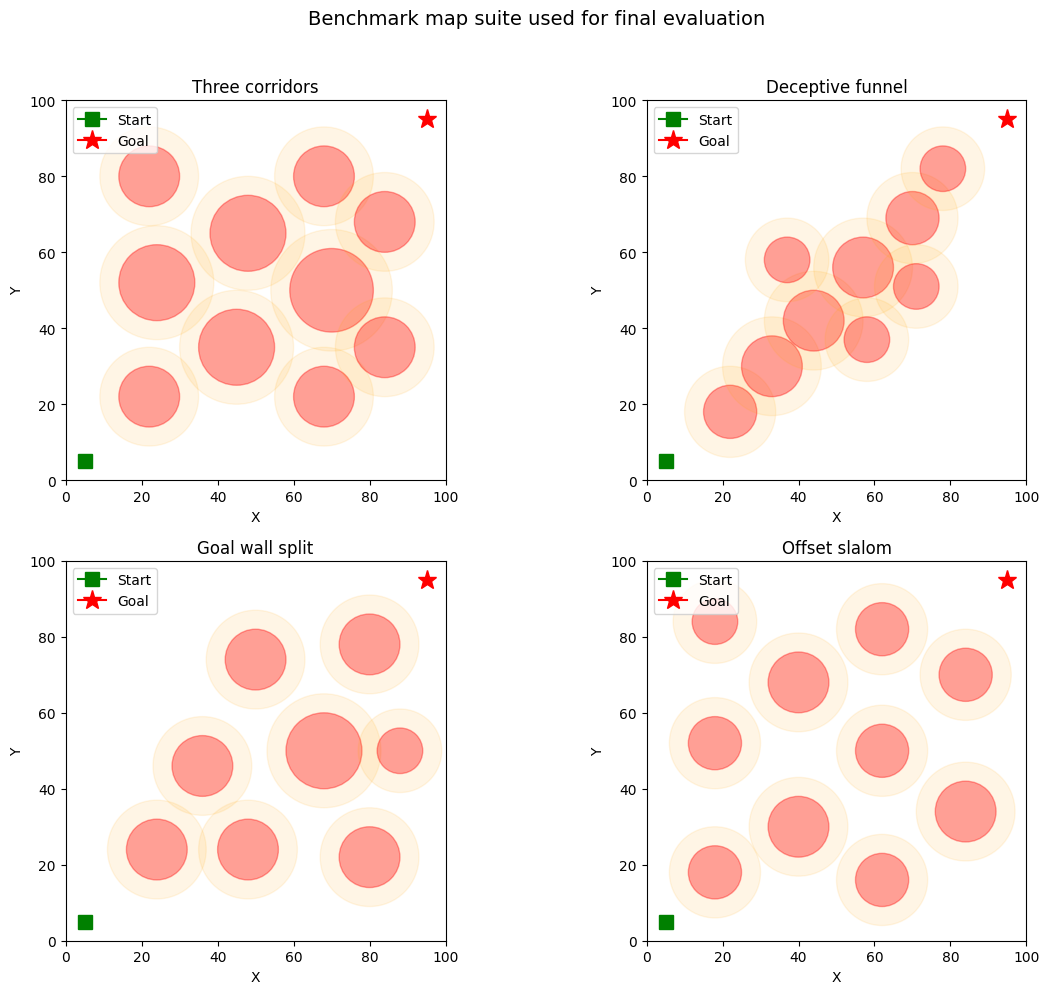

,map,note,obstacle_count,occupancy_ratio,overlap_pairs,min_pair_gap,direct_line_collisions
0,Three corridors,"Separated low, middle, and high corridor options.",10,0.252898,0,1.518285,2
1,Deceptive funnel,A central funnel that looks attractive early a...,9,0.136345,0,0.278821,6
2,Goal wall split,A late barrier near the goal creates a delayed...,8,0.163363,0,4.000000,3
3,Offset slalom,Alternating gaps with offset centerlines and n...,10,0.163991,0,10.059928,2


In [8]:
def make_map_config(
    obstacles: Sequence[CircleObstacle],
    n_waypoints: int,
    danger_margin: float | None = None,
    required_clearance: float | None = None,
) -> MapConfig:
    cfg = replace(config, n_waypoints=n_waypoints, obstacles=tuple(obstacles))
    if danger_margin is not None or required_clearance is not None:
        cfg = replace(
            cfg,
            danger_margin=cfg.danger_margin if danger_margin is None else float(danger_margin),
            required_clearance=cfg.required_clearance if required_clearance is None else float(required_clearance),
        )
    assert not point_inside_any_obstacle(cfg.start, cfg.obstacles)
    assert not point_inside_any_obstacle(cfg.goal, cfg.obstacles)
    return cfg


BENCHMARK_MAP_SPECS = {
    "Three corridors": {
        "description": "Separated low, middle, and high corridor options.",
        "obstacles": (
            CircleObstacle(22, 22, 8),
            CircleObstacle(24, 52, 10),
            CircleObstacle(22, 80, 8),
            CircleObstacle(45, 35, 10),
            CircleObstacle(48, 65, 10),
            CircleObstacle(68, 22, 8),
            CircleObstacle(70, 50, 11),
            CircleObstacle(68, 80, 8),
            CircleObstacle(84, 35, 8),
            CircleObstacle(84, 68, 8),
        ),
    },
    "Deceptive funnel": {
        "description": "A central funnel that looks attractive early and constricts late.",
        "obstacles": (
            CircleObstacle(22, 18, 7),
            CircleObstacle(33, 30, 8),
            CircleObstacle(44, 42, 8),
            CircleObstacle(57, 56, 8),
            CircleObstacle(70, 69, 7),
            CircleObstacle(58, 37, 6),
            CircleObstacle(71, 51, 6),
            CircleObstacle(37, 58, 6),
            CircleObstacle(78, 82, 6),
        ),
    },
    "Goal wall split": {
        "description": "A late barrier near the goal creates a delayed route split.",
        "obstacles": (
            CircleObstacle(24, 24, 8),
            CircleObstacle(36, 46, 8),
            CircleObstacle(48, 24, 8),
            CircleObstacle(50, 74, 8),
            CircleObstacle(68, 50, 10),
            CircleObstacle(80, 22, 8),
            CircleObstacle(80, 78, 8),
            CircleObstacle(88, 50, 6),
        ),
    },
    "Offset slalom": {
        "description": "Alternating gaps with offset centerlines and no single obvious lane.",
        "obstacles": (
            CircleObstacle(18, 18, 7),
            CircleObstacle(18, 52, 7),
            CircleObstacle(18, 84, 6),
            CircleObstacle(40, 30, 8),
            CircleObstacle(40, 68, 8),
            CircleObstacle(62, 16, 7),
            CircleObstacle(62, 50, 7),
            CircleObstacle(62, 82, 7),
            CircleObstacle(84, 34, 8),
            CircleObstacle(84, 70, 7),
        ),
    },
}


def obstacle_occupancy_ratio(obstacles: Sequence[CircleObstacle], map_size: float) -> float:
    return float(sum(math.pi * obs.radius * obs.radius for obs in obstacles) / (map_size * map_size))


def pairwise_obstacle_gaps(obstacles: Sequence[CircleObstacle]) -> list[float]:
    gaps = []
    for i, obs_i in enumerate(obstacles):
        for obs_j in obstacles[i + 1 :]:
            gaps.append(math.hypot(obs_i.cx - obs_j.cx, obs_i.cy - obs_j.cy) - (obs_i.radius + obs_j.radius))
    return gaps


def direct_line_clearances(map_config: MapConfig) -> list[float]:
    return [obs.clearance_to_segment(map_config.start, map_config.goal) for obs in map_config.obstacles]


def build_map_suite(base_waypoints: int = config.n_waypoints) -> dict[str, MapConfig]:
    return {
        name: make_map_config(spec["obstacles"], n_waypoints=base_waypoints)
        for name, spec in BENCHMARK_MAP_SPECS.items()
    }
benchmark_map_suite = build_map_suite(base_waypoints=config.n_waypoints)
benchmark_map_notes = {name: spec["description"] for name, spec in BENCHMARK_MAP_SPECS.items()}

benchmark_map_summary = []
for map_name, map_config in benchmark_map_suite.items():
    gaps = pairwise_obstacle_gaps(map_config.obstacles)
    direct_clearances = direct_line_clearances(map_config)
    benchmark_map_summary.append(
        {
            "map": map_name,
            "note": benchmark_map_notes[map_name],
            "obstacle_count": len(map_config.obstacles),
            "occupancy_ratio": obstacle_occupancy_ratio(map_config.obstacles, map_config.size),
            "overlap_pairs": int(sum(gap < 0.0 for gap in gaps)),
            "min_pair_gap": float(min(gaps)) if gaps else np.nan,
            "direct_line_collisions": int(sum(clearance <= 0.0 for clearance in direct_clearances)),
        }
    )

benchmark_map_summary = pd.DataFrame(benchmark_map_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (map_name, map_config) in zip(axes.flat, benchmark_map_suite.items()):
    plot_environment(ax, map_config, title=map_name)
fig.suptitle("Benchmark map suite used for final evaluation", fontsize=14, y=0.99)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

benchmark_map_summary


In [9]:
def config_signature(config: MapConfig) -> dict:
    return {
        "n_waypoints": int(config.n_waypoints),
        "danger_margin": float(config.danger_margin),
        "required_clearance": float(config.required_clearance),
    }


def saved_state_matches_config(state: dict | None, config: MapConfig) -> bool:
    if not state:
        return False
    return state.get("signature", {}) == config_signature(config)


def resolve_run_profile(profile: dict, map_config: MapConfig) -> dict:
    resolved = dict(profile)
    mutation_prob_factor = resolved.pop("mutation_prob_factor", None)
    if "mutation_prob" not in resolved and mutation_prob_factor is not None:
        resolved["mutation_prob"] = float(mutation_prob_factor) / (2 * map_config.n_waypoints)
    return resolved





def aggregate_algorithm_runs(run_df: pd.DataFrame) -> dict:
    return {
        "feasible_run_rate": float(run_df["has_feasible"].mean()),
        "median_feasible_count": float(run_df["feasible_count"].median()),
        "median_shortest_feasible_length": float(run_df["shortest_feasible_length"].median()),
        "median_safest_clearance": float(run_df["safest_feasible_min_clearance"].median()),
    }


def run_single_algorithm_multi_seed(run_fn, config: MapConfig, seeds, **run_kwargs) -> pd.DataFrame:
    rows = []
    for seed in seeds:
        res = run_fn(config, seed=seed, **run_kwargs)
        rows.append({"seed": seed, **summarize_population_for_comparison(res, config)})
    return pd.DataFrame(rows)


def rank_ga_weight_results(summary_df: pd.DataFrame) -> pd.DataFrame:
    return summary_df.sort_values(
        ["feasible_run_rate", "median_shortest_feasible_length", "median_safest_clearance", "w_risk"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)


TUNING_SEEDS = list(SAVED_EXPERIMENT_STATE["seed_sets"]["tuning"])
EVALUATION_SEEDS = list(SAVED_EXPERIMENT_STATE["seed_sets"]["evaluation"])
COMMON_PROTOCOL = dict(SAVED_EXPERIMENT_STATE["common_protocol"])
GA_WEIGHT_GRID = [float(weight) for weight in SAVED_EXPERIMENT_STATE["ga_weight_grid"]]
REPAIR_PROFILE = dict(SAVED_EXPERIMENT_STATE["repair_profile"])

use_saved_tuning = bool(EXPERIMENT_OPTIONS.get("use_saved_tuning", True))
saved_state_is_valid = saved_state_matches_config(SAVED_EXPERIMENT_STATE, config)
if use_saved_tuning and not saved_state_is_valid:
    print("Saved tuning does not match the active map signature. Recomputing the tuning screen.")
    use_saved_tuning = False

if use_saved_tuning:
    selected_ga_weight = float(SAVED_EXPERIMENT_STATE["selected_ga_weight"])
    ga_tuning_summary = pd.DataFrame(
        [
            {
                "selection_source": "saved registry",
                "w_risk": selected_ga_weight,
                "feasible_run_rate": np.nan,
                "median_shortest_feasible_length": np.nan,
                "median_safest_clearance": np.nan,
            }
        ]
    )
else:
    tuning_rows = []
    for w_risk in GA_WEIGHT_GRID:
        run_kwargs = resolve_run_profile(
            {
                **COMMON_PROTOCOL,
                "weights": (1.0, float(w_risk)),
                "heuristic_mode": "none",
                "repair_kind": "none",
            },
            config,
        )
        tuning_df = run_single_algorithm_multi_seed(run_ga, config, TUNING_SEEDS, **run_kwargs)
        tuning_rows.append({"w_risk": float(w_risk), **aggregate_algorithm_runs(tuning_df)})

    ga_tuning_summary = rank_ga_weight_results(pd.DataFrame(tuning_rows))
    selected_ga_weight = float(ga_tuning_summary.iloc[0]["w_risk"])

baseline_profiles = {
    "GA": {
        **COMMON_PROTOCOL,
        "weights": (1.0, float(selected_ga_weight)),
        "heuristic_mode": "none",
        "repair_kind": "none",
    },
    "NSGA-II": {
        **COMMON_PROTOCOL,
        "heuristic_mode": "none",
        "repair_kind": "none",
    },
}
enhanced_profiles = {
    "GA": {
        **COMMON_PROTOCOL,
        "weights": (1.0, float(selected_ga_weight)),
        **REPAIR_PROFILE,
    },
    "NSGA-II": {
        **COMMON_PROTOCOL,
        **REPAIR_PROFILE,
    },
}

CONDITION_SPECS = {
    "GA baseline": {
        "comparison": "Baseline",
        "algorithm": "GA",
        "repair": "No repair",
        "run_fn": run_ga,
        "run_kwargs": resolve_run_profile(baseline_profiles["GA"], config),
    },
    "NSGA-II baseline": {
        "comparison": "Baseline",
        "algorithm": "NSGA-II",
        "repair": "No repair",
        "run_fn": run_nsga2,
        "run_kwargs": resolve_run_profile(baseline_profiles["NSGA-II"], config),
    },
    "GA + repair": {
        "comparison": "Enhanced",
        "algorithm": "GA",
        "repair": "SegmentAwareRepair",
        "run_fn": run_ga,
        "run_kwargs": resolve_run_profile(enhanced_profiles["GA"], config),
    },
    "NSGA-II + repair": {
        "comparison": "Enhanced",
        "algorithm": "NSGA-II",
        "repair": "SegmentAwareRepair",
        "run_fn": run_nsga2,
        "run_kwargs": resolve_run_profile(enhanced_profiles["NSGA-II"], config),
    },
}

for condition_name, spec in CONDITION_SPECS.items():
    assert int(spec["run_kwargs"]["pop_size"]) == int(COMMON_PROTOCOL["pop_size"])
    assert int(spec["run_kwargs"]["n_gen"]) == int(COMMON_PROTOCOL["n_gen"])

seed_table = pd.DataFrame(
    [
        {"role": "tuning", "n_seeds": len(TUNING_SEEDS), "seeds": tuple(TUNING_SEEDS)},
        {"role": "evaluation", "n_seeds": len(EVALUATION_SEEDS), "seeds": tuple(EVALUATION_SEEDS)},
    ]
)

protocol_table = pd.DataFrame(
    [
        {
            "condition": name,
            "comparison": spec["comparison"],
            "algorithm": spec["algorithm"],
            "repair": spec["repair"],
            "pop_size": int(spec["run_kwargs"]["pop_size"]),
            "n_gen": int(spec["run_kwargs"]["n_gen"]),
            "function_evaluations": int(spec["run_kwargs"]["pop_size"]) * int(spec["run_kwargs"]["n_gen"]),
            "weights": spec["run_kwargs"].get("weights", np.nan),
            "crossover_eta": float(spec["run_kwargs"]["crossover_eta"]),
            "mutation_eta": float(spec["run_kwargs"]["mutation_eta"]),
            "mutation_prob": float(spec["run_kwargs"]["mutation_prob"]),
        }
        for name, spec in CONDITION_SPECS.items()
    ]
)



print("Seed split")
print(seed_table.to_string(index=False))
print()
print("Shared protocol and conditions")
print(protocol_table.to_string(index=False))
print()
print(f"GA risk-weight source: {'saved registry' if use_saved_tuning else 'recomputed on the development map'}")
print(f"Selected GA risk weight = {selected_ga_weight:.1f}")
if not use_saved_tuning:
    print()
    print("GA weight tuning screen")
    print(ga_tuning_summary.to_string(index=False))



protocol_table


Seed split
      role  n_seeds                                                                                                seeds
    tuning        6                                                                                   (0, 1, 2, 3, 4, 5)
evaluation       20 (100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119)

Shared protocol and conditions
       condition comparison algorithm             repair  pop_size  n_gen  function_evaluations     weights  crossover_eta  mutation_eta  mutation_prob
     GA baseline   Baseline        GA          No repair        80     80                  6400 (1.0, 80.0)           15.0          20.0         0.0625
NSGA-II baseline   Baseline   NSGA-II          No repair        80     80                  6400         NaN           15.0          20.0         0.0625
     GA + repair   Enhanced        GA SegmentAwareRepair        80     80                  6400 (1.0, 80.0)           15.0          20.0  

,condition,comparison,algorithm,repair,pop_size,n_gen,function_evaluations,weights,crossover_eta,mutation_eta,mutation_prob
0,GA baseline,Baseline,GA,No repair,80,80,6400,"(1.0, 80.0)",15.0,20.0,0.0625
1,NSGA-II baseline,Baseline,NSGA-II,No repair,80,80,6400,NaN,15.0,20.0,0.0625
2,GA + repair,Enhanced,GA,SegmentAwareRepair,80,80,6400,"(1.0, 80.0)",15.0,20.0,0.0625
3,NSGA-II + repair,Enhanced,NSGA-II,SegmentAwareRepair,80,80,6400,NaN,15.0,20.0,0.0625


In [10]:
test_obstacle = CircleObstacle(5.0, 0.0, 5.0)

geometry_checks = pd.DataFrame(
    [
        {"case": "outside point", "value": test_obstacle.signed_distance_to_point((11.0, 0.0)), "expected": 1.0},
        {"case": "boundary point", "value": test_obstacle.signed_distance_to_point((10.0, 0.0)), "expected": 0.0},
        {"case": "inside point", "value": test_obstacle.signed_distance_to_point((5.0, 0.0)), "expected": -5.0},
        {"case": "tangent segment clearance", "value": test_obstacle.clearance_to_segment((0.0, 5.0), (10.0, 5.0)), "expected": 0.0},
        {"case": "crossing segment clearance", "value": test_obstacle.clearance_to_segment((0.0, 0.0), (10.0, 0.0)), "expected": -5.0},
        {"case": "clear segment clearance", "value": test_obstacle.clearance_to_segment((0.0, 7.0), (10.0, 7.0)), "expected": 2.0},
        {"case": "zero-length boundary segment", "value": test_obstacle.clearance_to_segment((0.0, 0.0), (0.0, 0.0)), "expected": 0.0},
    ]
)

assert math.isclose(test_obstacle.signed_distance_to_point((11.0, 0.0)), 1.0, abs_tol=1e-9)
assert math.isclose(test_obstacle.signed_distance_to_point((10.0, 0.0)), 0.0, abs_tol=1e-9)
assert math.isclose(test_obstacle.signed_distance_to_point((5.0, 0.0)), -5.0, abs_tol=1e-9)
assert math.isclose(test_obstacle.clearance_to_segment((0.0, 5.0), (10.0, 5.0)), 0.0, abs_tol=1e-9)
assert test_obstacle.intersects_segment((0.0, 5.0), (10.0, 5.0))
assert math.isclose(test_obstacle.clearance_to_segment((0.0, 0.0), (10.0, 0.0)), -5.0, abs_tol=1e-9)
assert test_obstacle.intersects_segment((0.0, 0.0), (10.0, 0.0))
assert math.isclose(test_obstacle.clearance_to_segment((0.0, 7.0), (10.0, 7.0)), 2.0, abs_tol=1e-9)
assert not test_obstacle.intersects_segment((0.0, 7.0), (10.0, 7.0))
assert math.isclose(test_obstacle.clearance_to_segment((0.0, 0.0), (0.0, 0.0)), 0.0, abs_tol=1e-9)

print("CircleObstacle edge-case checks passed.")
geometry_checks


CircleObstacle edge-case checks passed.


,case,value,expected
0,outside point,1.0,1.0
1,boundary point,0.0,0.0
2,inside point,-5.0,-5.0
3,tangent segment clearance,0.0,0.0
4,crossing segment clearance,-5.0,-5.0
5,clear segment clearance,2.0,2.0
6,zero-length boundary segment,0.0,0.0


## 7. Baseline comparison results

This section answers the first half of the research question under the strict baseline protocol:

- `GA baseline`
- `NSGA-II baseline`

Both conditions use the same benchmark maps, the same seeds, the same waypoint representation, the same initialization strategy, the same population size, and the same total function-evaluation budget. Neither method receives repair assistance here.

The benchmark summaries and paired comparisons are the primary evidence. The representative gallery that follows is included as a visual interpretation aid rather than as a substitute for the aggregated benchmark tables.

In [11]:
ROUTE_CHECKPOINTS = (20.0, 40.0, 60.0, 80.0)


def interpolate_y_at_x(path: Sequence[Point], x_target: float) -> float:
    hits: list[tuple[float, float]] = []

    for p1, p2 in path_segments(path):
        x1, y1 = p1
        x2, y2 = p2
        if min(x1, x2) - 1e-9 <= x_target <= max(x1, x2) + 1e-9:
            if abs(x2 - x1) < 1e-9:
                hits.append((abs(x1 - x_target), 0.5 * (y1 + y2)))
            else:
                t = (x_target - x1) / (x2 - x1)
                if -1e-9 <= t <= 1.0 + 1e-9:
                    hits.append((abs(t - 0.5), y1 + t * (y2 - y1)))

    if hits:
        hits.sort(key=lambda item: item[0])
        return float(hits[0][1])

    return float(min(path, key=lambda point: abs(point[0] - x_target))[1])


def classify_y_band(y_value: float, map_size: float = config.size) -> str:
    if y_value < map_size / 3.0:
        return "low"
    if y_value < 2.0 * map_size / 3.0:
        return "mid"
    return "high"


def route_family_signature(path: Sequence[Point], checkpoints: Sequence[float] = ROUTE_CHECKPOINTS) -> str:
    """Assign a coarse corridor label from fixed x-checkpoints."""
    bands = [classify_y_band(interpolate_y_at_x(path, checkpoint)) for checkpoint in checkpoints]
    return "-".join(bands)

def extract_feasible_share_history(res, config: MapConfig) -> np.ndarray:
    ratios = []
    for algo in res.history:
        X = np.asarray(algo.pop.get("X"))
        feasible = [evaluate_decision_vector(x, config).feasible for x in X]
        ratios.append(float(np.mean(feasible)))
    return np.asarray(ratios, dtype=float)


def plot_nsga_objective_space(res, config: MapConfig, title_prefix: str):
    representatives, table, _ = pick_nsga2_representatives(res, config)
    feasible_mask = table["feasible"].to_numpy(dtype=bool)
    all_objectives = table[["length", "danger_penalty"]].to_numpy(dtype=float)

    if feasible_mask.any():
        reference = all_objectives[feasible_mask]
    else:
        reference = all_objectives

    marker_specs = {
        "shortest": ("s", "tab:green", "Shortest feasible"),
        "safest": ("^", "tab:orange", "Safest feasible"),
        "compromise": ("*", "tab:red", "Compromise"),
    }

    def draw_panel(ax, x_values, y_values, title: str):
        if (~feasible_mask).any():
            ax.scatter(
                x_values[~feasible_mask],
                y_values[~feasible_mask],
                color="lightgray",
                edgecolors="black",
                label="Not feasible",
            )
        ax.scatter(
            x_values[feasible_mask],
            y_values[feasible_mask],
            color="tab:blue",
            edgecolors="black",
            label="Feasible candidates",
        )
        for key, (marker, color, label) in marker_specs.items():
            rep = representatives[key]
            if rep is None:
                continue
            metrics = rep["metrics"]
            rep_x = metrics.length
            rep_y = metrics.danger_penalty
            ax.scatter([rep_x], [rep_y], marker=marker, s=220, color=color, edgecolors="black", label=label)
        ax.set_title(title)
        ax.grid(alpha=0.3)

    fig, ax = plt.subplots(1, 1, figsize=(6.8, 5))
    draw_panel(ax, all_objectives[:, 0], all_objectives[:, 1], title=f"{title_prefix}: raw objective space")
    ax.set_xlabel("Path length")
    ax.set_ylabel("Danger penalty")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return table


def summarize_population_with_route_diversity(res, map_config: MapConfig):
    X, F = get_final_population(res)
    table = solution_set_table(X, F, map_config).copy()
    table["route_family"] = [
        route_family_signature(decode_solution(np.asarray(x), map_config))
        for x in np.atleast_2d(X)
    ]

    summary = summarize_population_for_comparison(res, map_config)
    feasible_table = table.loc[table["feasible"]]
    summary["feasible_route_family_count"] = int(feasible_table["route_family"].nunique()) if not feasible_table.empty else 0
    summary["dominant_feasible_route_family"] = feasible_table["route_family"].mode().iat[0] if not feasible_table.empty else "none"

    representative_map = {
        "shortest_feasible": select_shortest_feasible_idx(table),
        "safest_feasible": select_safest_feasible_idx(table),
        "compromise": select_compromise_feasible_idx(table),
    }
    for prefix, idx in representative_map.items():
        summary[f"{prefix}_route_family"] = "none" if idx is None else str(table.loc[idx, "route_family"])

    return summary, table


def run_condition_suite(
    map_suite: dict[str, MapConfig],
    seeds,
    condition_specs: dict[str, dict],
    collect_population: bool = False,
):
    run_rows = []
    population_tables = []

    for map_name, map_config in map_suite.items():
        for condition_name, spec in condition_specs.items():
            for seed in seeds:
                res = spec["run_fn"](map_config, seed=seed, **spec["run_kwargs"])
                summary, table = summarize_population_with_route_diversity(res, map_config)
                run_rows.append(
                    {
                        "map": map_name,
                        "condition": condition_name,
                        "comparison": spec["comparison"],
                        "algorithm": spec["algorithm"],
                        "repair": spec["repair"],
                        "seed": seed,
                        "n_waypoints": map_config.n_waypoints,
                        **summary,
                    }
                )
                if collect_population:
                    population_tables.append(
                        table.assign(
                            map=map_name,
                            condition=condition_name,
                            comparison=spec["comparison"],
                            algorithm=spec["algorithm"],
                            repair=spec["repair"],
                            seed=seed,
                            n_waypoints=map_config.n_waypoints,
                        )
                    )

    run_df = pd.DataFrame(run_rows)
    population_df = pd.concat(population_tables, ignore_index=True) if population_tables else pd.DataFrame()
    return run_df, population_df


def aggregate_condition_summary(run_df: pd.DataFrame, group_cols: Sequence[str]) -> pd.DataFrame:
    rows = []
    for keys, group in run_df.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        dominant_mode = group["dominant_feasible_route_family"].mode()
        row.update(
            {
                "feasible_run_rate": float(group["has_feasible"].mean()),
                "median_feasible_count": float(group["feasible_count"].median()),
                "q1_feasible_count": float(group["feasible_count"].quantile(0.25)),
                "q3_feasible_count": float(group["feasible_count"].quantile(0.75)),
                "median_shortest_feasible_length": float(group["shortest_feasible_length"].median()),
                "q1_shortest_feasible_length": float(group["shortest_feasible_length"].quantile(0.25)),
                "q3_shortest_feasible_length": float(group["shortest_feasible_length"].quantile(0.75)),
                "median_safest_clearance": float(group["safest_feasible_min_clearance"].median()),
                "q1_safest_clearance": float(group["safest_feasible_min_clearance"].quantile(0.25)),
                "q3_safest_clearance": float(group["safest_feasible_min_clearance"].quantile(0.75)),
                "mean_route_family_count": float(group["feasible_route_family_count"].mean()),
                "dominant_route_family": dominant_mode.iat[0] if not dominant_mode.empty else "none",
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


def select_display_seed(run_df: pd.DataFrame, map_name: str, condition_name: str) -> int:
    """Choose a representative feasible run for gallery display within one condition."""
    subset = run_df.loc[(run_df["map"] == map_name) & (run_df["condition"] == condition_name)].copy()
    if subset["has_feasible"].any():
        subset = subset.loc[subset["has_feasible"]].copy()

    target_length = float(subset["shortest_feasible_length"].median(skipna=True))
    subset["length_gap"] = (subset["shortest_feasible_length"] - target_length).abs().fillna(np.inf)
    subset = subset.sort_values(
        ["length_gap", "feasible_count", "safest_feasible_min_clearance", "seed"],
        ascending=[True, False, False, True],
    )
    return int(subset.iloc[0]["seed"])


def annotate_path_panel(ax, metrics: PathMetrics, route_family: str):
    ax.text(
        0.02,
        0.02,
        f"L={metrics.length:.1f}\nclr={metrics.min_clearance:.2f}\nfamily={route_family}",
        transform=ax.transAxes,
        va="bottom",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="gray", alpha=0.85),
    )


Development-map illustrative seed = 100

GA baseline incumbent
  overall feasible    = yes
  collision-free      = yes
  clearance-feasible  = yes
  length              = 329.460
  clearance penalty   = 0.400
  min clearance       = 2.369
  collision segments  = 0
  selection           = GA incumbent from weighted optimization

NSGA-II baseline final population
  candidates            = 80
  geometric-feasible    = 80
  safety-feasible       = 80


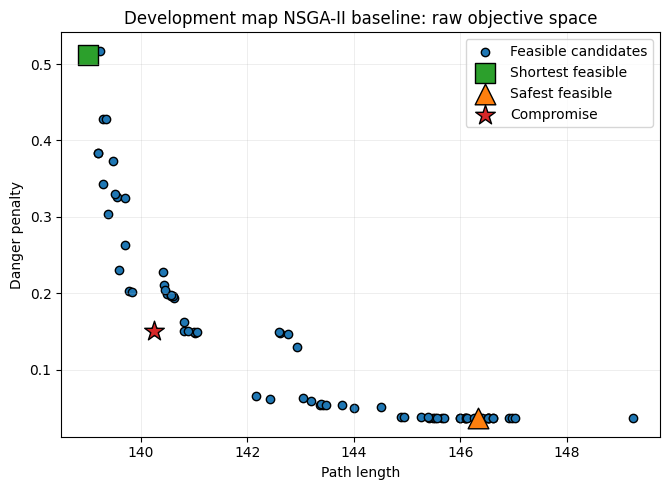

,idx,length,danger_penalty,min_clearance,collision_segments,collision_violation,clearance_violation,out_of_bounds_violation,in_bounds,geometric_feasible,clearance_feasible,feasible,weighted_score,f1,f2
0,0,145.653608,0.036784,4.118567,0,0.0,0.0,0.0,True,True,True,True,150.067716,145.653608,0.036784
1,1,145.407868,0.037111,4.117466,0,0.0,0.0,0.0,True,True,True,True,149.861180,145.407868,0.037111
2,2,139.189165,0.383700,2.162754,0,0.0,0.0,0.0,True,True,True,True,185.233187,139.189165,0.383700
3,3,146.329461,0.036328,4.119479,0,0.0,0.0,0.0,True,True,True,True,150.688802,146.329461,0.036328
4,4,145.258581,0.037241,4.117233,0,0.0,0.0,0.0,True,True,True,True,149.727558,145.258581,0.037241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,139.558617,0.326437,2.379302,0,0.0,0.0,0.0,True,True,True,True,178.731039,139.558617,0.326437
76,76,139.694947,0.324029,2.394492,0,0.0,0.0,0.0,True,True,True,True,178.578477,139.694947,0.324029
77,77,139.475086,0.373033,2.190813,0,0.0,0.0,0.0,True,True,True,True,184.239097,139.475086,0.373033
78,78,139.518866,0.329715,2.371818,0,0.0,0.0,0.0,True,True,True,True,179.084678,139.518866,0.329715


In [12]:
demo_seed = EVALUATION_SEEDS[0]
ga_demo_res = CONDITION_SPECS["GA baseline"]["run_fn"](config, seed=demo_seed, **CONDITION_SPECS["GA baseline"]["run_kwargs"])
nsga_demo_res = CONDITION_SPECS["NSGA-II baseline"]["run_fn"](config, seed=demo_seed, **CONDITION_SPECS["NSGA-II baseline"]["run_kwargs"])

ga_demo_x, ga_demo_metrics, ga_demo_meta = pick_ga_incumbent(ga_demo_res, config, weights=CONDITION_SPECS["GA baseline"]["run_kwargs"]["weights"])
nsga_demo_reps, nsga_demo_table, nsga_demo_meta = pick_nsga2_representatives(nsga_demo_res, config)

print(f"Development-map illustrative seed = {demo_seed}")
print()
print_solution_summary("GA baseline incumbent", ga_demo_metrics, {"selection": ga_demo_meta["selection_label"]})
print()
print("NSGA-II baseline final population")
print(f"  candidates            = {nsga_demo_meta['candidate_count']}")
print(f"  geometric-feasible    = {nsga_demo_meta['collision_free_count']}")
print(f"  safety-feasible       = {nsga_demo_meta['feasible_count']}")

plot_nsga_objective_space(nsga_demo_res, config, title_prefix="Development map NSGA-II baseline")


In [13]:
def plot_comparison_gallery(run_df: pd.DataFrame, comparison_name: str):
    """Show one GA incumbent and three NSGA-II representatives for each benchmark map."""
    ordered_maps = list(benchmark_map_suite.keys())
    ga_condition = "GA baseline" if comparison_name == "Baseline" else "GA + repair"
    nsga_condition = "NSGA-II baseline" if comparison_name == "Baseline" else "NSGA-II + repair"

    fig, axes = plt.subplots(len(ordered_maps), 4, figsize=(16.5, 4.2 * len(ordered_maps)))
    axes = np.atleast_2d(axes)
    header_positions = [0.17, 0.41, 0.64, 0.87]
    column_headers = [
        f"{ga_condition}\nWeighted incumbent",
        f"{nsga_condition}\nShortest feasible",
        f"{nsga_condition}\nSafest feasible",
        f"{nsga_condition}\nCompromise",
    ]
    for x_pos, header in zip(header_positions, column_headers):
        fig.text(x_pos, 0.965, header, ha="center", va="top", fontsize=10.5, fontweight="bold")

    for row, map_name in enumerate(ordered_maps):
        map_config = benchmark_map_suite[map_name]
        axes[row, 0].text(
            -0.34,
            0.5,
            map_name,
            transform=axes[row, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=11,
            fontweight="bold",
        )

        ga_seed = select_display_seed(run_df, map_name, ga_condition)
        nsga_seed = select_display_seed(run_df, map_name, nsga_condition)

        ga_spec = CONDITION_SPECS[ga_condition]
        nsga_spec = CONDITION_SPECS[nsga_condition]
        ga_res = ga_spec["run_fn"](map_config, seed=ga_seed, **ga_spec["run_kwargs"])
        nsga_res = nsga_spec["run_fn"](map_config, seed=nsga_seed, **nsga_spec["run_kwargs"])

        ga_weights = ga_spec["run_kwargs"].get("weights", GA_WEIGHTS)
        ga_x, ga_metrics, _ = pick_ga_incumbent(ga_res, map_config, weights=ga_weights)
        ga_path = decode_solution(ga_x, map_config)
        plot_environment(axes[row, 0], map_config, ga_path, title=f"Seed {ga_seed}")
        if axes[row, 0].legend_ is not None:
            axes[row, 0].legend_.remove()
        annotate_path_panel(axes[row, 0], ga_metrics, route_family_signature(ga_path))

        nsga_reps, _, _ = pick_nsga2_representatives(nsga_res, map_config)
        for rep_key, col in [("shortest", 1), ("safest", 2), ("compromise", 3)]:
            rep = nsga_reps[rep_key]
            ax = axes[row, col]
            if rep is None:
                plot_environment(ax, map_config, title=f"Seed {nsga_seed}")
                if ax.legend_ is not None:
                    ax.legend_.remove()
                ax.text(0.5, 0.5, "No feasible\nrepresentative", ha="center", va="center")
                continue
            plot_environment(ax, map_config, rep["path"], title=f"Seed {nsga_seed}")
            if ax.legend_ is not None:
                ax.legend_.remove()
            annotate_path_panel(ax, rep["metrics"], route_family_signature(rep["path"]))

    fig.suptitle(f"{comparison_name} representative path gallery", fontsize=14, y=0.995)
    plt.tight_layout(rect=(0.03, 0.0, 1.0, 0.92))
    plt.show()


def paired_bootstrap_ci(values: Sequence[float], n_boot: int = 2000, seed: int = 2026) -> tuple[float, float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(n_boot, len(values)))
    boot_means = values[indices].mean(axis=1)
    return float(values.mean()), float(np.quantile(boot_means, 0.025)), float(np.quantile(boot_means, 0.975))


def paired_effect_table(run_df: pd.DataFrame, left_condition: str, right_condition: str) -> pd.DataFrame:
    metric_specs = [
        ("has_feasible", "Feasible run indicator", "higher"),
        ("shortest_feasible_length", "Shortest feasible length", "lower"),
        ("safest_feasible_min_clearance", "Safest feasible clearance", "higher"),
        ("feasible_count", "Feasible candidates in final population", "higher"),
    ]

    rows = []
    for metric, label, better in metric_specs:
        aligned = (
            run_df.loc[run_df["condition"].isin([left_condition, right_condition]), ["map", "seed", "condition", metric]]
            .pivot_table(index=["map", "seed"], columns="condition", values=metric)
        )
        if left_condition not in aligned.columns or right_condition not in aligned.columns:
            diff = np.array([], dtype=float)
        else:
            diff = (aligned[right_condition] - aligned[left_condition]).to_numpy(dtype=float)
        mean_diff, ci_low, ci_high = paired_bootstrap_ci(diff)
        rows.append(
            {
                "comparison": f"{right_condition} minus {left_condition}",
                "metric": label,
                "better_direction": better,
                "n_pairs": int(np.isfinite(diff).sum()),
                "mean_difference": mean_diff,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )
    return pd.DataFrame(rows)


def plot_condition_dumbbell(ax, summary_df: pd.DataFrame, left_condition: str, right_condition: str, metric: str, title: str, xlabel: str):
    ordered_maps = list(benchmark_map_suite.keys())
    y_positions = np.arange(len(ordered_maps))
    left_values = []
    right_values = []

    for y, map_name in enumerate(ordered_maps):
        subset = summary_df.loc[summary_df["map"] == map_name].set_index("condition")
        left_value = float(subset.loc[left_condition, metric])
        right_value = float(subset.loc[right_condition, metric])
        left_values.append(left_value)
        right_values.append(right_value)
        ax.plot([left_value, right_value], [y, y], color="0.70", linewidth=2, zorder=1)

    ax.scatter(left_values, y_positions, color="#4c78a8", s=60, label=left_condition, zorder=3)
    ax.scatter(right_values, y_positions, color="#f58518", marker="D", s=60, label=right_condition, zorder=3)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(ordered_maps)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.3, axis="x")


benchmark_runs, benchmark_population = run_condition_suite(
    benchmark_map_suite,
    EVALUATION_SEEDS,
    CONDITION_SPECS,
    collect_population=True,
)
baseline_runs = benchmark_runs.loc[benchmark_runs["comparison"] == "Baseline"].copy()
enhanced_runs = benchmark_runs.loc[benchmark_runs["comparison"] == "Enhanced"].copy()
overall_condition_summary = aggregate_condition_summary(benchmark_runs, ["comparison", "condition"]).sort_values(["comparison", "condition"]).reset_index(drop=True)

print("Benchmark evaluation summary")
print(overall_condition_summary[["comparison", "condition", "feasible_run_rate", "median_shortest_feasible_length", "median_safest_clearance", "mean_route_family_count"]].to_string(index=False))

overall_condition_summary

Benchmark evaluation summary
comparison        condition  feasible_run_rate  median_shortest_feasible_length  median_safest_clearance  mean_route_family_count
  Baseline      GA baseline             0.9875                       170.810755                 4.811108                   1.1125
  Baseline NSGA-II baseline             0.9125                       164.668346                 5.050749                   1.2125
  Enhanced      GA + repair             1.0000                       174.922612                 4.871355                   1.1000
  Enhanced NSGA-II + repair             1.0000                       166.484456                 5.111058                   1.1875


,comparison,condition,feasible_run_rate,median_feasible_count,q1_feasible_count,q3_feasible_count,median_shortest_feasible_length,q1_shortest_feasible_length,q3_shortest_feasible_length,median_safest_clearance,q1_safest_clearance,q3_safest_clearance,mean_route_family_count,dominant_route_family
0,Baseline,GA baseline,0.9875,80.0,80.0,80.0,170.810755,156.501590,196.562468,4.811108,4.427913,5.143948,1.1125,high-high-high-high
1,Baseline,NSGA-II baseline,0.9125,80.0,80.0,80.0,164.668346,153.731799,202.850426,5.050749,4.944483,5.379773,1.2125,high-high-high-high
2,Enhanced,GA + repair,1.0000,80.0,80.0,80.0,174.922612,162.147499,208.190674,4.871355,4.393042,5.755126,1.1000,high-high-high-high
3,Enhanced,NSGA-II + repair,1.0000,80.0,80.0,80.0,166.484456,155.352868,184.116023,5.111058,5.009116,5.963037,1.1875,high-high-high-high


Baseline summary by map
             map        condition  feasible_run_rate  median_shortest_feasible_length  median_safest_clearance  mean_route_family_count
Deceptive funnel      GA baseline               1.00                       164.773047                 5.028126                     1.20
Deceptive funnel NSGA-II baseline               1.00                       158.561054                 5.407729                     1.20
 Goal wall split      GA baseline               1.00                       158.772280                 5.213737                     1.05
 Goal wall split NSGA-II baseline               1.00                       155.989713                 5.194477                     1.05
   Offset slalom      GA baseline               1.00                       216.990915                 3.944858                     1.20
   Offset slalom NSGA-II baseline               0.95                       219.085239                 4.610867                     1.80
 Three corridors      GA

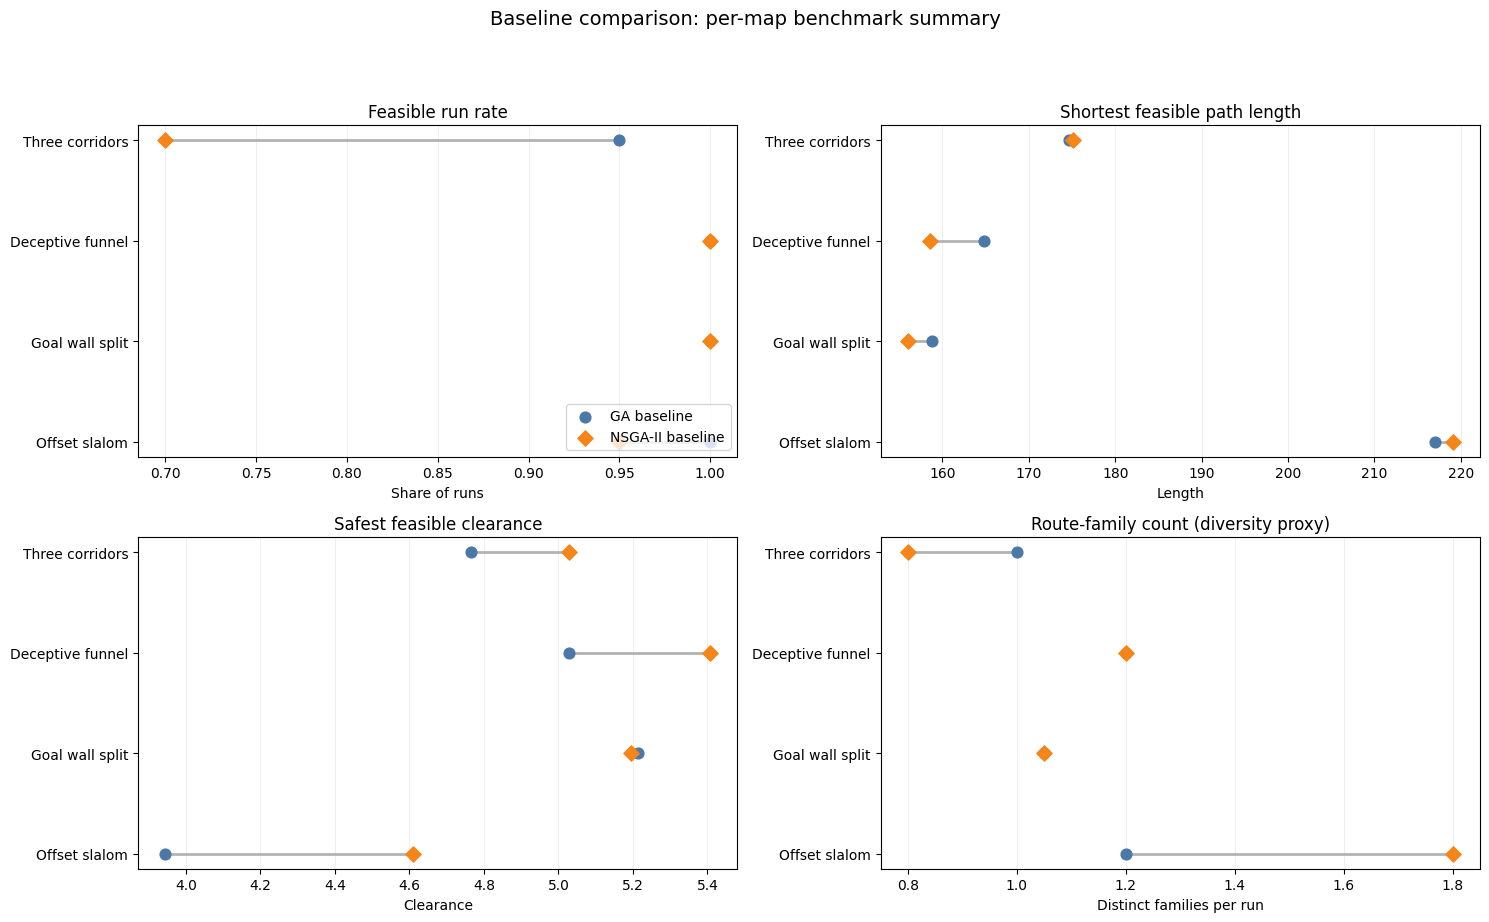

,condition,feasible_run_rate,median_feasible_count,q1_feasible_count,q3_feasible_count,median_shortest_feasible_length,q1_shortest_feasible_length,q3_shortest_feasible_length,median_safest_clearance,q1_safest_clearance,q3_safest_clearance,mean_route_family_count,dominant_route_family
0,GA baseline,0.9875,80.0,80.0,80.0,170.810755,156.501590,196.562468,4.811108,4.427913,5.143948,1.1125,high-high-high-high
1,NSGA-II baseline,0.9125,80.0,80.0,80.0,164.668346,153.731799,202.850426,5.050749,4.944483,5.379773,1.2125,high-high-high-high


In [14]:
baseline_summary = aggregate_condition_summary(baseline_runs, ["map", "condition"]).sort_values(["map", "condition"]).reset_index(drop=True)
baseline_overall = aggregate_condition_summary(baseline_runs, ["condition"]).sort_values("condition").reset_index(drop=True)
baseline_effect_table = paired_effect_table(baseline_runs, "GA baseline", "NSGA-II baseline")

print("Baseline summary by map")
print(baseline_summary[["map", "condition", "feasible_run_rate", "median_shortest_feasible_length", "median_safest_clearance", "mean_route_family_count"]].to_string(index=False))
print()
print("Baseline overall summary")
print(baseline_overall[["condition", "feasible_run_rate", "median_shortest_feasible_length", "median_safest_clearance", "mean_route_family_count"]].to_string(index=False))
print()
print("Baseline paired effects")
print(baseline_effect_table.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
baseline_metric_specs = [
    ("feasible_run_rate", "Feasible run rate", "Share of runs"),
    ("median_shortest_feasible_length", "Shortest feasible path length", "Length"),
    ("median_safest_clearance", "Safest feasible clearance", "Clearance"),
    ("mean_route_family_count", "Route-family count (diversity proxy)", "Distinct families per run"),
]
for ax, (metric, title, xlabel) in zip(axes.flat, baseline_metric_specs):
    plot_condition_dumbbell(ax, baseline_summary, "GA baseline", "NSGA-II baseline", metric, title, xlabel)
axes[0, 0].legend(loc="lower right")
fig.suptitle("Baseline comparison: per-map benchmark summary", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

baseline_overall

### Baseline interpretation

GA is slightly stronger in baseline feasible robustness, as seen in its higher feasible-run rate. NSGA-II, however, tends to retain stronger feasible representatives when it succeeds, with shorter shortest-feasible paths, slightly better safety, and a modest diversity advantage on the benchmark summaries.

This is a trade-off statement rather than a universal ranking, and the benchmark summaries suggest that the path-quality edge should be interpreted directionally rather than as a large guaranteed margin on every map.

In [ ]:
plot_comparison_gallery(baseline_runs, "Baseline")

**Figure note.** Baseline gallery. The left column shows the GA weighted incumbent. The three NSGA-II columns show the shortest feasible, safest feasible, and compromise representatives from the final feasible set. Display seeds are chosen within each condition by proximity to that condition's median shortest feasible path, so the gallery is illustrative rather than a separate evaluation metric.

## 8. Enhanced comparison results

This section repeats the same fair comparison after adding the same obstacle-aware offspring repair operator to both algorithms:

- `GA + repair`
- `NSGA-II + repair`

The purpose is not to create a different experimental world for each algorithm. The purpose is to test whether one shared geometric enhancement changes feasible robustness or representative path quality under the same budget and seed protocol.

### Development-map feasibility diagnostic

The plot below is retained because it helps explain the role of repair. It is an illustrative diagnostic on the development map, not part of the benchmark evidence used for the final baseline or enhanced comparison.

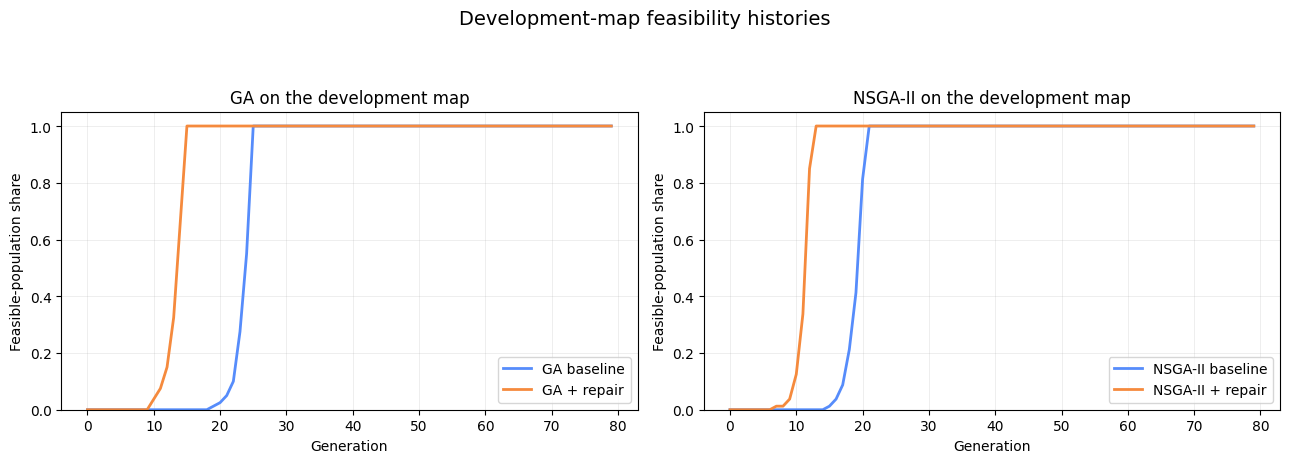

In [16]:
demo_seed = EVALUATION_SEEDS[0]
ga_base_demo = CONDITION_SPECS["GA baseline"]["run_fn"](config, seed=demo_seed, **CONDITION_SPECS["GA baseline"]["run_kwargs"])
ga_repair_demo = CONDITION_SPECS["GA + repair"]["run_fn"](config, seed=demo_seed, **CONDITION_SPECS["GA + repair"]["run_kwargs"])
nsga_base_demo = CONDITION_SPECS["NSGA-II baseline"]["run_fn"](config, seed=demo_seed, **CONDITION_SPECS["NSGA-II baseline"]["run_kwargs"])
nsga_repair_demo = CONDITION_SPECS["NSGA-II + repair"]["run_fn"](config, seed=demo_seed, **CONDITION_SPECS["NSGA-II + repair"]["run_kwargs"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(extract_feasible_share_history(ga_base_demo, config), label="GA baseline", linewidth=2)
axes[0].plot(extract_feasible_share_history(ga_repair_demo, config), label="GA + repair", linewidth=2)
axes[0].set_title("GA on the development map")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Feasible-population share")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="lower right")

axes[1].plot(extract_feasible_share_history(nsga_base_demo, config), label="NSGA-II baseline", linewidth=2)
axes[1].plot(extract_feasible_share_history(nsga_repair_demo, config), label="NSGA-II + repair", linewidth=2)
axes[1].set_title("NSGA-II on the development map")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Feasible-population share")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
axes[1].legend(loc="lower right")

fig.suptitle("Development-map feasibility histories", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

Enhanced summary by map
             map        condition  feasible_run_rate  median_shortest_feasible_length  median_safest_clearance  mean_route_family_count
Deceptive funnel      GA + repair                1.0                       166.139855                 6.167332                     1.05
Deceptive funnel NSGA-II + repair                1.0                       151.856675                 5.370397                     1.05
 Goal wall split      GA + repair                1.0                       157.630960                 5.048663                     1.10
 Goal wall split NSGA-II + repair                1.0                       159.442521                 7.086108                     1.15
   Offset slalom      GA + repair                1.0                       217.630706                 4.423311                     1.15
   Offset slalom NSGA-II + repair                1.0                       213.813564                 4.492141                     1.55
 Three corridors      GA

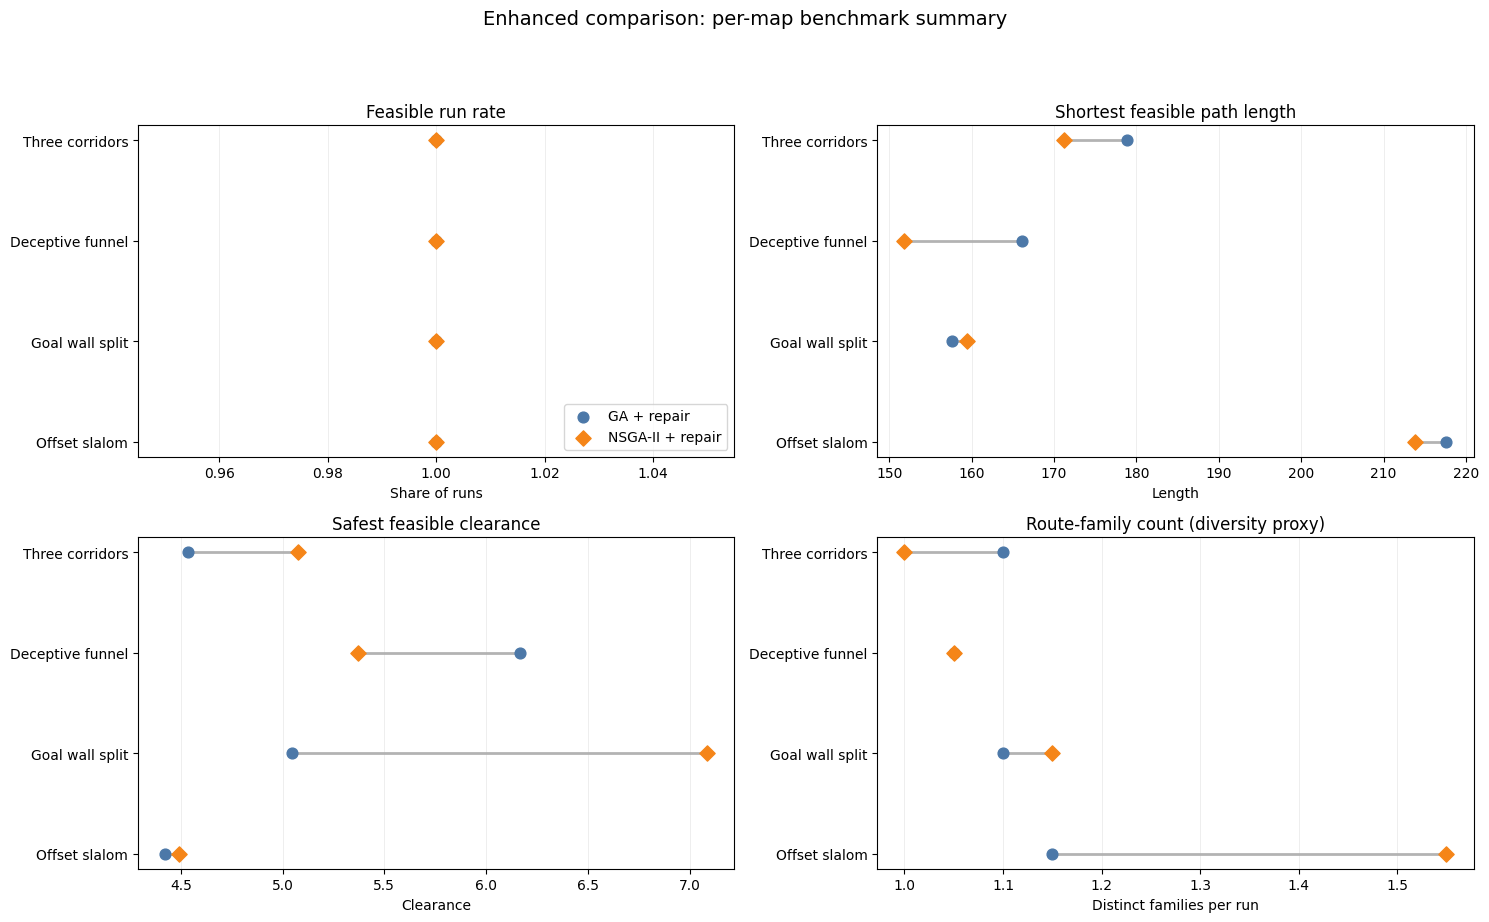

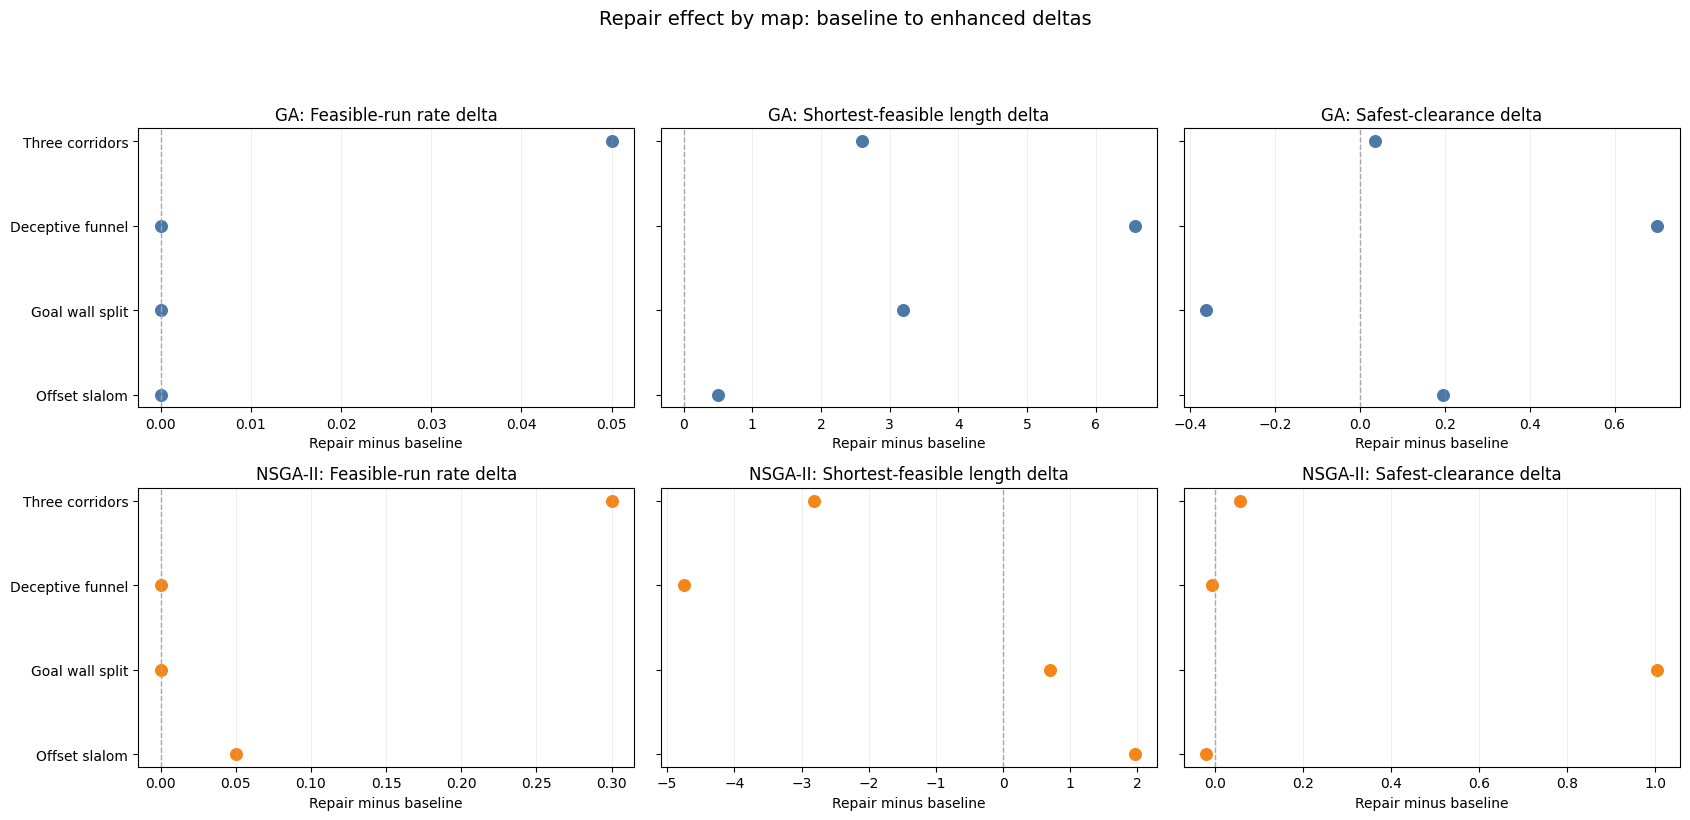

,condition,feasible_run_rate,median_feasible_count,q1_feasible_count,q3_feasible_count,median_shortest_feasible_length,q1_shortest_feasible_length,q3_shortest_feasible_length,median_safest_clearance,q1_safest_clearance,q3_safest_clearance,mean_route_family_count,dominant_route_family
0,GA + repair,1.0,80.0,80.0,80.0,174.922612,162.147499,208.190674,4.871355,4.393042,5.755126,1.1000,high-high-high-high
1,NSGA-II + repair,1.0,80.0,80.0,80.0,166.484456,155.352868,184.116023,5.111058,5.009116,5.963037,1.1875,high-high-high-high


In [17]:
enhanced_summary = aggregate_condition_summary(enhanced_runs, ["map", "condition"]).sort_values(["map", "condition"]).reset_index(drop=True)
enhanced_overall = aggregate_condition_summary(enhanced_runs, ["condition"]).sort_values("condition").reset_index(drop=True)
enhanced_effect_table = paired_effect_table(enhanced_runs, "GA + repair", "NSGA-II + repair")

repair_effect_table = pd.concat(
    [
        paired_effect_table(benchmark_runs.loc[benchmark_runs["algorithm"] == "GA"], "GA baseline", "GA + repair").assign(algorithm="GA"),
        paired_effect_table(benchmark_runs.loc[benchmark_runs["algorithm"] == "NSGA-II"], "NSGA-II baseline", "NSGA-II + repair").assign(algorithm="NSGA-II"),
    ],
    ignore_index=True,
)


def repair_delta_by_map(run_df: pd.DataFrame, algorithm_name: str, metric: str, reducer: str) -> pd.Series:
    subset = run_df.loc[run_df["algorithm"] == algorithm_name].copy()
    aligned = subset.pivot_table(index=["map", "seed"], columns="repair", values=metric)
    delta = aligned["SegmentAwareRepair"] - aligned["No repair"]
    if reducer == "mean":
        return delta.groupby(level="map").mean()
    return delta.groupby(level="map").median()


repair_delta_summary = []
for algorithm_name in ["GA", "NSGA-II"]:
    for metric, reducer in [
        ("has_feasible", "mean"),
        ("shortest_feasible_length", "median"),
        ("safest_feasible_min_clearance", "median"),
    ]:
        delta_series = repair_delta_by_map(benchmark_runs, algorithm_name, metric, reducer)
        for map_name, value in delta_series.items():
            repair_delta_summary.append(
                {
                    "algorithm": algorithm_name,
                    "map": map_name,
                    "metric": metric,
                    "delta_repair_minus_baseline": float(value),
                }
            )
repair_delta_summary = pd.DataFrame(repair_delta_summary)

print("Enhanced summary by map")
print(enhanced_summary[["map", "condition", "feasible_run_rate", "median_shortest_feasible_length", "median_safest_clearance", "mean_route_family_count"]].to_string(index=False))
print()
print("Enhanced overall summary")
print(enhanced_overall[["condition", "feasible_run_rate", "median_shortest_feasible_length", "median_safest_clearance", "mean_route_family_count"]].to_string(index=False))
print()
print("Enhanced paired effects")
print(enhanced_effect_table.to_string(index=False))
print()
print("Repair effects by algorithm")
print(repair_effect_table.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
enhanced_metric_specs = [
    ("feasible_run_rate", "Feasible run rate", "Share of runs"),
    ("median_shortest_feasible_length", "Shortest feasible path length", "Length"),
    ("median_safest_clearance", "Safest feasible clearance", "Clearance"),
    ("mean_route_family_count", "Route-family count (diversity proxy)", "Distinct families per run"),
]
for ax, (metric, title, xlabel) in zip(axes.flat, enhanced_metric_specs):
    plot_condition_dumbbell(ax, enhanced_summary, "GA + repair", "NSGA-II + repair", metric, title, xlabel)
axes[0, 0].legend(loc="lower right")
fig.suptitle("Enhanced comparison: per-map benchmark summary", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharey="row")
delta_metric_specs = [
    ("has_feasible", "Feasible-run rate delta", "Repair minus baseline"),
    ("shortest_feasible_length", "Shortest-feasible length delta", "Repair minus baseline"),
    ("safest_feasible_min_clearance", "Safest-clearance delta", "Repair minus baseline"),
]
ordered_maps = list(benchmark_map_suite.keys())
for row, algorithm_name in enumerate(["GA", "NSGA-II"]):
    for col, (metric, title, xlabel) in enumerate(delta_metric_specs):
        ax = axes[row, col]
        subset = repair_delta_summary.loc[
            (repair_delta_summary["algorithm"] == algorithm_name) & (repair_delta_summary["metric"] == metric)
        ].set_index("map").reindex(ordered_maps)
        values = subset["delta_repair_minus_baseline"].to_numpy(dtype=float)
        y_positions = np.arange(len(ordered_maps))
        ax.axvline(0.0, color="0.65", linestyle="--", linewidth=1)
        ax.scatter(values, y_positions, color="#4c78a8" if algorithm_name == "GA" else "#f58518", s=70)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(ordered_maps)
        ax.invert_yaxis()
        ax.set_title(f"{algorithm_name}: {title}")
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.3, axis="x")

fig.suptitle("Repair effect by map: baseline to enhanced deltas", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

enhanced_overall

### Enhanced interpretation

With the shared repair operator, both algorithms reach full feasible-run rate on this benchmark suite. The clearest effect of repair is improved robustness rather than dramatic raw path shortening: feasibility improves, safety often improves, and length changes are smaller and more map-dependent.

NSGA-II still retains the stronger representative-path profile after repair, especially on shortest-feasible path length and safest feasible clearance.

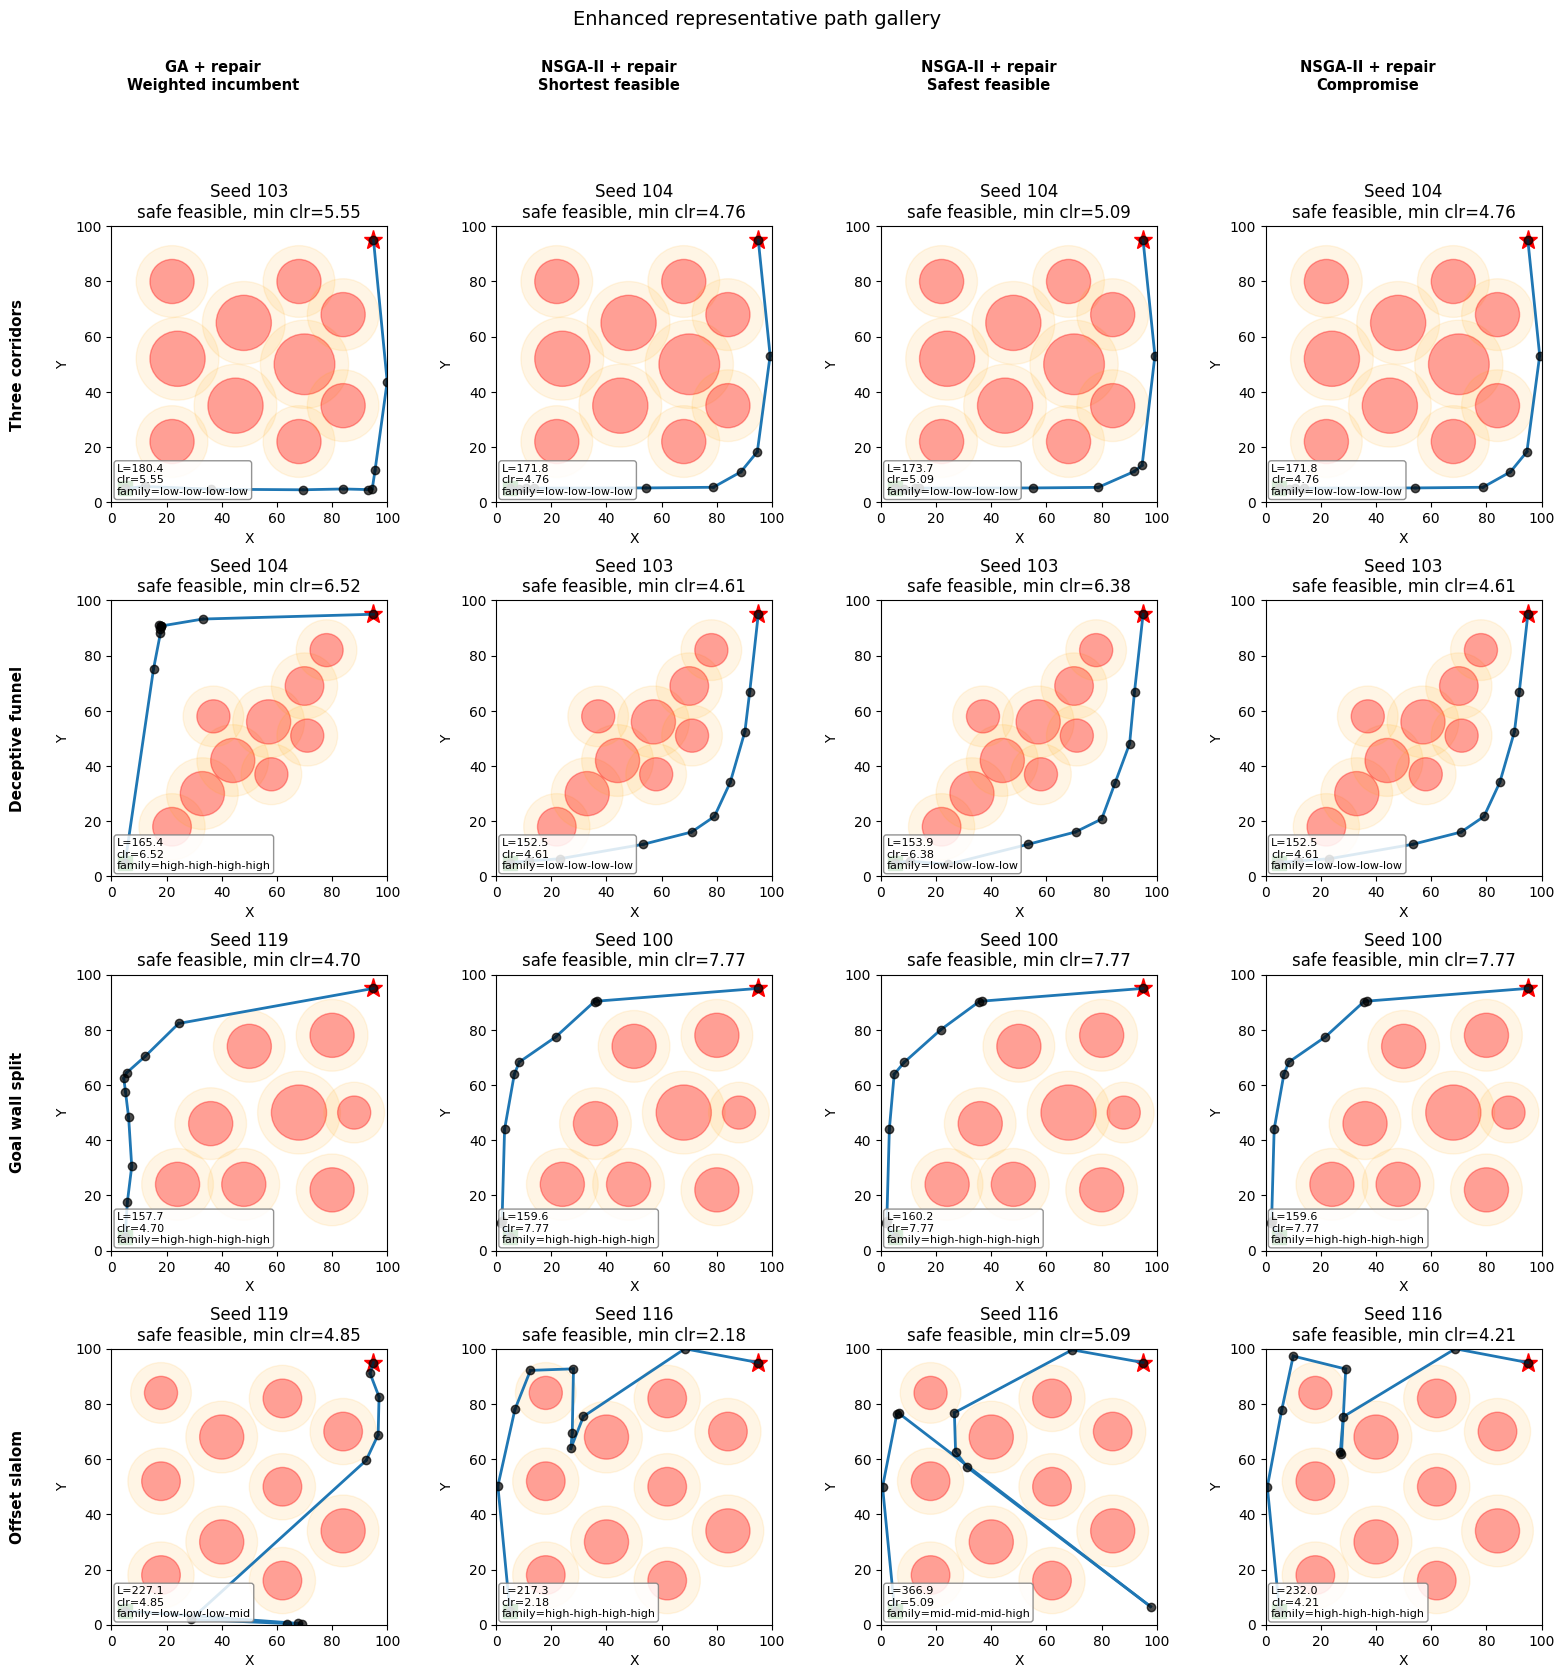

In [18]:
plot_comparison_gallery(enhanced_runs, "Enhanced")

**Figure note.** Enhanced gallery. The layout matches the baseline gallery so that changes in representative-path behavior can be read column by column. The figure is used to interpret the benchmark summaries rather than to override them.

## 9. Optional exploratory analyses

The analyses below are useful for interpretation, but they are not the primary evidence block for the report. They are kept deliberately secondary so that the main claims rest on the benchmark summaries from Sections 7 and 8.

### Route-family definition

Route families are an **interpretive** diversity proxy rather than a standard optimization metric. Each path is labeled by the vertical band it occupies at four fixed `x`-checkpoints, producing a signature such as `low-low-mid-high`.

This label is useful for asking whether the final population spans multiple geometric corridors, but it should not be confused with a formal topological proof. It is supporting evidence for diversity behavior and is not used as the primary ranking criterion between algorithms.

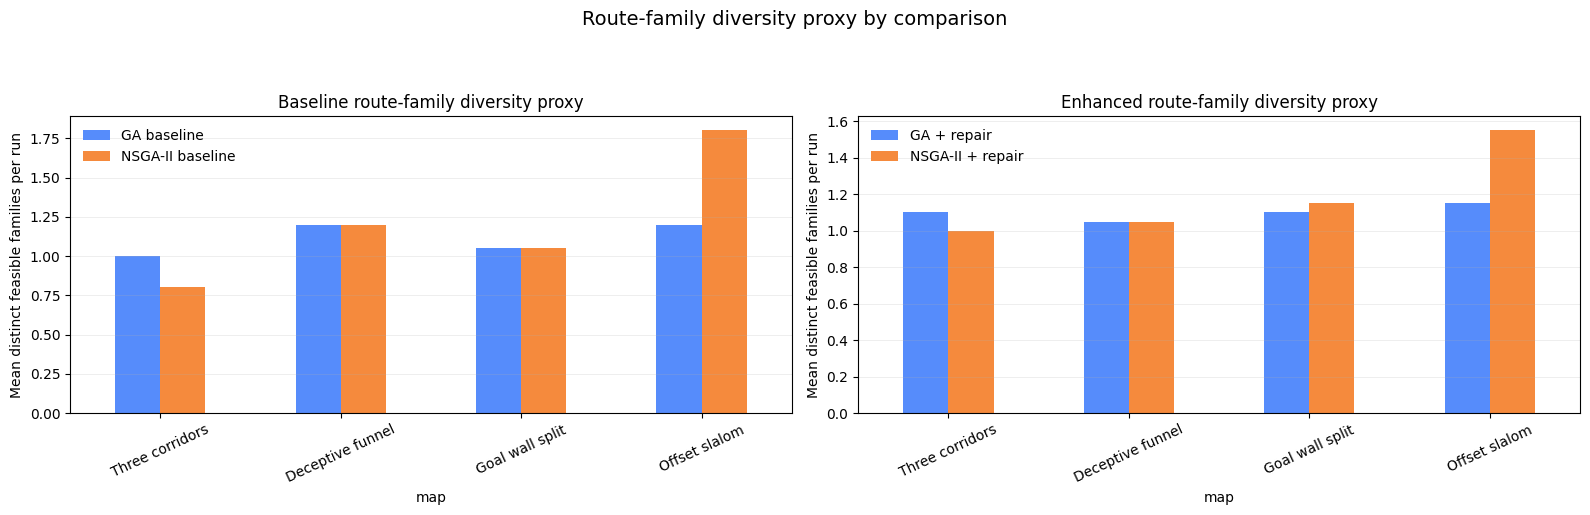

Route-family summary
comparison        condition              map  mean_route_family_count dominant_shortest_family dominant_safest_family
  Baseline      GA baseline Deceptive funnel                     1.20       mid-high-high-high    high-high-high-high
  Baseline NSGA-II baseline Deceptive funnel                     1.20       mid-high-high-high     mid-high-high-high
  Baseline      GA baseline  Goal wall split                     1.05      high-high-high-high    high-high-high-high
  Baseline NSGA-II baseline  Goal wall split                     1.05      high-high-high-high    high-high-high-high
  Baseline      GA baseline    Offset slalom                     1.20         mid-mid-mid-high       mid-mid-mid-high
  Baseline NSGA-II baseline    Offset slalom                     1.80        low-mid-high-high       low-low-mid-high
  Baseline      GA baseline  Three corridors                     1.00      high-high-high-high    high-high-high-high
  Baseline NSGA-II baseline  Three 

,comparison,condition,map,mean_route_family_count,dominant_shortest_family,dominant_safest_family
0,Baseline,GA baseline,Deceptive funnel,1.20,mid-high-high-high,high-high-high-high
1,Baseline,NSGA-II baseline,Deceptive funnel,1.20,mid-high-high-high,mid-high-high-high
2,Baseline,GA baseline,Goal wall split,1.05,high-high-high-high,high-high-high-high
3,Baseline,NSGA-II baseline,Goal wall split,1.05,high-high-high-high,high-high-high-high
4,Baseline,GA baseline,Offset slalom,1.20,mid-mid-mid-high,mid-mid-mid-high
5,Baseline,NSGA-II baseline,Offset slalom,1.80,low-mid-high-high,low-low-mid-high
6,Baseline,GA baseline,Three corridors,1.00,high-high-high-high,high-high-high-high
7,Baseline,NSGA-II baseline,Three corridors,0.80,low-low-low-low,low-low-low-low
8,Enhanced,GA + repair,Deceptive funnel,1.05,high-high-high-high,high-high-high-high
9,Enhanced,NSGA-II + repair,Deceptive funnel,1.05,high-high-high-high,high-high-high-high


In [19]:
route_summary = (
    benchmark_runs.groupby(["comparison", "condition", "map"], as_index=False)
    .agg(
        mean_route_family_count=("feasible_route_family_count", "mean"),
        dominant_shortest_family=("shortest_feasible_route_family", lambda s: s.mode().iat[0] if not s.mode().empty else "none"),
        dominant_safest_family=("safest_feasible_route_family", lambda s: s.mode().iat[0] if not s.mode().empty else "none"),
    )
    .sort_values(["comparison", "map", "condition"])
    .reset_index(drop=True)
)

feasible_population = benchmark_population.loc[benchmark_population["feasible"]].copy()
top_route_families = (
    feasible_population.groupby(["condition", "route_family"])
    .size()
    .reset_index(name="candidate_count")
    .sort_values(["condition", "candidate_count", "route_family"], ascending=[True, False, True])
    .groupby("condition")
    .head(3)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, comparison_name in zip(axes, ["Baseline", "Enhanced"]):
    subset = route_summary.loc[route_summary["comparison"] == comparison_name]
    pivot = subset.pivot(index="map", columns="condition", values="mean_route_family_count").loc[list(benchmark_map_suite.keys())]
    pivot.plot(kind="bar", ax=ax, rot=25)
    ax.set_title(f"{comparison_name} route-family diversity proxy")
    ax.set_ylabel("Mean distinct feasible families per run")
    ax.grid(alpha=0.3, axis="y")
    ax.legend(frameon=False)

fig.suptitle("Route-family diversity proxy by comparison", fontsize=14, y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print("Route-family summary")
print(route_summary.to_string(index=False))
print()
print("Most common feasible route families")
print(top_route_families.to_string(index=False))

route_summary

**Interpretive note.** Route-family counts summarize coarse corridor usage at fixed `x`-checkpoints. They provide heuristic support for diversity claims, especially when NSGA-II preserves multiple corridor choices, but they are not a formal topological analysis and they are not the primary basis for judging algorithm quality.

## 10. Limitations and threats to validity

These conclusions remain bounded by the study design.

- The problem is 2D and ignores flight dynamics, turning limits, wind, and control effort.
- Obstacles are circles, which makes the geometry exact but also simplifies the environment.
- The path representation uses a fixed waypoint count, which may bias the search space.
- Only one repair operator is studied, so the repair conclusion does not generalize to every obstacle-aware heuristic.
- The benchmark map suite is hand-designed and intentionally small, so it is suitable for a compact experimental study but not for broad external claims.
- The weighted-sum GA requires a scalarization weight, so part of the modeling burden lies in choosing `w_R`. NSGA-II does not carry this burden in the same form.
- GA is evaluated through a scalarized incumbent, whereas NSGA-II is interpreted through representatives drawn from a Pareto set. Part of NSGA-II's strength in this notebook therefore lies in preserving trade-offs and yielding stronger representatives across objectives rather than in finding one universally best path.
- Route-family counts are heuristic corridor labels rather than formal topological classes, so they are used as supporting diversity evidence only.
- In the current benchmark suite, the algorithms are separated more clearly in solution quality and diversity than in basic feasibility. Feasible-run rates are already high, so the benchmark is more informative about trade-offs among good paths than about whether an algorithm can find any feasible path at all.
- The notebook reports paired uncertainty summaries, but it is still a modest experimental study rather than a large empirical benchmark.

Within those limits, the notebook still supports a defensible project-scale comparison as long as the claims remain local, precise, and tied to the evidence shown here.

## 11. Conclusion

Under the fair baseline protocol, the weighted-sum GA shows slightly stronger feasible-run robustness, while NSGA-II more often supplies stronger shortest-feasible, safety-oriented, and diversity-oriented representatives. After the same repair operator is added to both methods, the feasible-run gap closes, and the clearest effect of repair is improved robustness rather than dramatic raw path shortening.

The overall conclusion is therefore a trade-off statement rather than a universal ranking. GA remains a credible scalar baseline when a single preferred trade-off is required. NSGA-II is more compelling when the goal is to retain multiple feasible trade-offs and then choose among strong representatives. Both findings remain local to this simplified 2D benchmark suite with circular obstacles and fixed waypoint paths.

In [20]:
overall_condition_view = overall_condition_summary.set_index("condition")

final_takeaways = pd.DataFrame(
    [
        {
            "question": "Baseline comparison",
            "answer": (
                f"Under the fair no-repair protocol, GA baseline kept the slightly higher feasible-run rate "
                f"({overall_condition_view.loc['GA baseline', 'feasible_run_rate']:.2f} vs "
                f"{overall_condition_view.loc['NSGA-II baseline', 'feasible_run_rate']:.2f}), while NSGA-II baseline produced the shorter median shortest feasible path "
                f"({overall_condition_view.loc['NSGA-II baseline', 'median_shortest_feasible_length']:.1f} vs "
                f"{overall_condition_view.loc['GA baseline', 'median_shortest_feasible_length']:.1f}) and the higher median safest clearance "
                f"({overall_condition_view.loc['NSGA-II baseline', 'median_safest_clearance']:.2f} vs "
                f"{overall_condition_view.loc['GA baseline', 'median_safest_clearance']:.2f})."
            ),
        },
        {
            "question": "Enhanced comparison",
            "answer": (
                f"With the shared repair operator, both methods reached a feasible-run rate of "
                f"{overall_condition_view.loc['GA + repair', 'feasible_run_rate']:.2f}. NSGA-II + repair still retained the stronger representative path profile, with a shorter median shortest feasible path "
                f"({overall_condition_view.loc['NSGA-II + repair', 'median_shortest_feasible_length']:.1f} vs "
                f"{overall_condition_view.loc['GA + repair', 'median_shortest_feasible_length']:.1f}) and a higher median safest clearance "
                f"({overall_condition_view.loc['NSGA-II + repair', 'median_safest_clearance']:.2f} vs "
                f"{overall_condition_view.loc['GA + repair', 'median_safest_clearance']:.2f})."
            ),
        },
        {
            "question": "Effect of repair",
            "answer": "Repair mainly improved robustness rather than raw path length: it removed the baseline feasibility gap and increased safety more clearly than it shortened paths, with the clearest gains appearing for NSGA-II.",
        },
        {
            "question": "Main interpretation",
            "answer": "The evidence supports a trade-off reading rather than a universal winner. GA is slightly stronger in baseline feasible robustness, whereas NSGA-II is stronger when judged by retained trade-offs and representative feasible path quality.",
        },
    ]
)

print("Overall condition summary")
print(overall_condition_summary[["comparison", "condition", "feasible_run_rate", "median_shortest_feasible_length", "median_safest_clearance", "mean_route_family_count"]].to_string(index=False))
print()
print("Final summary")
print(final_takeaways.to_string(index=False))

final_takeaways

Overall condition summary
comparison        condition  feasible_run_rate  median_shortest_feasible_length  median_safest_clearance  mean_route_family_count
  Baseline      GA baseline             0.9875                       170.810755                 4.811108                   1.1125
  Baseline NSGA-II baseline             0.9125                       164.668346                 5.050749                   1.2125
  Enhanced      GA + repair             1.0000                       174.922612                 4.871355                   1.1000
  Enhanced NSGA-II + repair             1.0000                       166.484456                 5.111058                   1.1875

Final summary
           question                                                                                                                                                                                                                                                                          answer
Baseline comparis

,question,answer
0,Baseline comparison,"Under the fair no-repair protocol, GA baseline..."
1,Enhanced comparison,"With the shared repair operator, both methods ..."
2,Effect of repair,Repair mainly improved robustness rather than ...
3,Main interpretation,The evidence supports a trade-off reading rath...
